# Network Slicing - Complete Analysis & Preparation

## 🎯 Objectif
Analyse complète et préparation du dataset network slicing v3 :
1. **Analyse exploratoire** des données brutes
2. **Détection** des valeurs manquantes/aberrantes
3. **Imputation** intelligente des valeurs manquantes
4. **Suppression** du biais (Use Case Type)
5. **Préparation** finale pour le Machine Learning

## 📁 Dataset
- **Source** : `network_slicing_dataset - v3_6G_OLD.csv`
- **Lignes** : 10 000
- **Colonnes** : 13 → 12 (après nettoyage)

## Part 1: Setup & Data Loading

In [1]:
## STEP 1 — Setup & Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("✅ Libraries imported successfully!")

# Load and convert dataset
df = pd.read_csv('network_slicing_dataset - v3_6G_OLD.csv', sep=';')

# Convert budget columns to numeric (handling comma decimal separator)
budget_columns = ['Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)','Data R date Budget (Gbps)']
for col in budget_columns:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")

✅ Libraries imported successfully!
📊 Dataset shape: (10000, 13)
📋 Columns: ['Use Case Type', 'Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (ns)', 'Slice Packet Loss', 'Slice Jitter (ns)', 'Slice Type', 'Slice Handover']


## STEP 2 — First Look at the Data

In [2]:
# Display dataset shape and columns
print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Column names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

📊 Dataset shape: (10000, 13)
📋 Column names:
   1. Use Case Type
   2. Packet Loss Budget
   3. Latency Budget (ns)
   4. Jitter Budget (ns)
   5. Data R date Budget (Gbps)
   6. Required Mobility
   7. Required Connectivity
   8. Slice Available Transfer Rate (Gbps)
   9. Slice Latency (ns)
  10. Slice Packet Loss
  11. Slice Jitter (ns)
  12. Slice Type
  13. Slice Handover


In [3]:
# Create a table for columns
columns_table = pd.DataFrame({
    "Index": range(1, len(df.columns) + 1),
    "Column Name": df.columns
})

# Display dataset shape
shape_table = pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Value": [df.shape[0], df.shape[1]]
})

print("📊 Dataset Shape:")
print(shape_table)

print("\n📋 Columns:")
print(columns_table)

📊 Dataset Shape:
    Metric  Value
0     Rows  10000
1  Columns     13

📋 Columns:
    Index                           Column Name
0       1                         Use Case Type
1       2                    Packet Loss Budget
2       3                   Latency Budget (ns)
3       4                    Jitter Budget (ns)
4       5             Data R date Budget (Gbps)
5       6                     Required Mobility
6       7                 Required Connectivity
7       8  Slice Available Transfer Rate (Gbps)
8       9                    Slice Latency (ns)
9      10                     Slice Packet Loss
10     11                     Slice Jitter (ns)
11     12                            Slice Type
12     13                        Slice Handover


## STEP 3 — Data Types & Basic Info

In [3]:
# Detailed dataset information
print("📈 Dataset Info:")
df.info()

print("\n📊 Basic Statistics:")
print(df.describe().round(3))

📈 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Use Case Type                         10000 non-null  object 
 1   Packet Loss Budget                    10000 non-null  float64
 2   Latency Budget (ns)                   10000 non-null  float64
 3   Jitter Budget (ns)                    10000 non-null  float64
 4   Data R date Budget (Gbps)             10000 non-null  float64
 5   Required Mobility                     10000 non-null  object 
 6   Required Connectivity                 10000 non-null  object 
 7   Slice Available Transfer Rate (Gbps)  10000 non-null  float64
 8   Slice Latency (ns)                    10000 non-null  float64
 9   Slice Packet Loss                     10000 non-null  float64
 10  Slice Jitter (ns)                     10000 non-null  float64
 11  

## STEP 4 — Target Variable Analysis (Slice Type)

🎯 Slice Type Distribution:
Slice Type
ERLLC     2262
feMBB     2237
umMTC     2204
MBRLLC    2203
mURLLC    1094
Name: count, dtype: int64

📊 Percentage Distribution:
Slice Type
ERLLC     22.62
feMBB     22.37
umMTC     22.04
MBRLLC    22.03
mURLLC    10.94
Name: count, dtype: float64


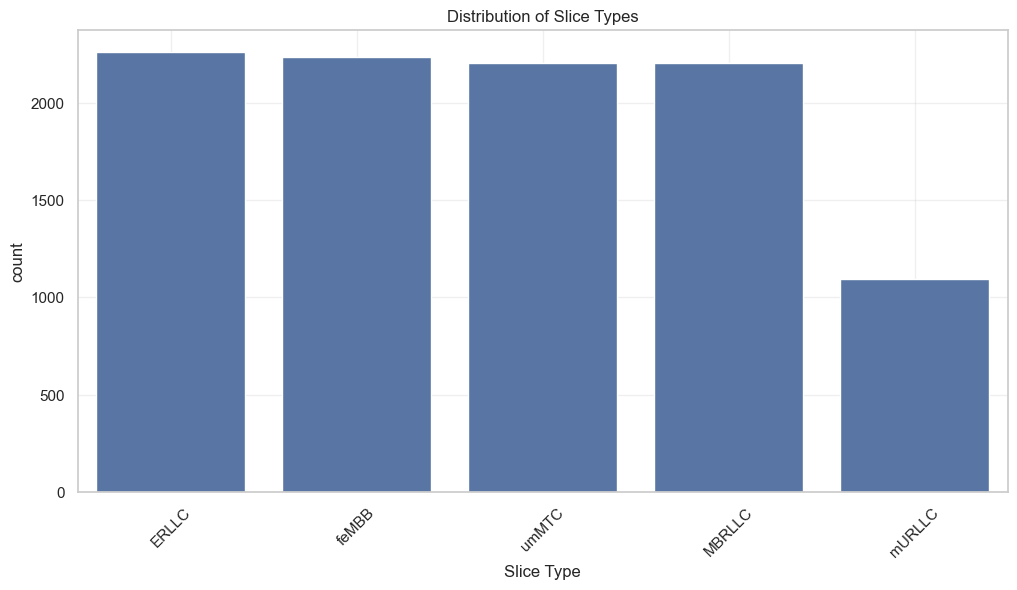

In [4]:
# Target variable distribution analysis
print("🎯 Slice Type Distribution:")
slice_counts = df["Slice Type"].value_counts()
print(slice_counts)

print("\n📊 Percentage Distribution:")
print((slice_counts / len(df) * 100).round(2))

# Visualization
plt.figure(figsize=(12, 6))
sns.countplot(x="Slice Type", data=df, order=slice_counts.index)
plt.title("Distribution of Slice Types")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()
plt.close()  # Close figure to free memory

## STEP 6 — Missing Values Check

In [5]:
## STEP 6 — Missing Values Check

In [6]:
# Check for missing values and zero values (potential missing data)
import pandas as pd
import numpy as np

# Set display options to prevent truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("❓ Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

if missing_values.sum() > 0:
    print("⚠️  Missing values detected!")
else:
    print("✅ No missing values found!")

print("\n🔍 ZERO VALUES ANALYSIS (Potential Missing Data):")
print("=" * 80)

# Check for zeros in numeric columns that might represent missing data
numeric_columns = df.select_dtypes(include=[np.number]).columns
zero_analysis = {}

for col in numeric_columns:
    zero_count = (df[col] == 0).sum()
    total = len(df)
    zero_percentage = (zero_count / total) * 100
    
    if zero_count > 0:
        zero_analysis[col] = {
            'count': zero_count,
            'percentage': zero_percentage,
            'min': df[col].min(),
            'max': df[col].max()
        }

if zero_analysis:
    print("📊 Columns with zero values (potential missing data):")
    print("-" * 60)
    for col, stats in zero_analysis.items():
        print(f"{col}:")
        print(f"  Zeros: {stats['count']} ({stats['percentage']:.2f}%)")
        print(f"  Range: [{stats['min']}, {stats['max']}]")
        print()
    
    print("🎯 SUMMARY TABLE:")
    print("=" * 80)
    print(f"{'Colonne':<35} {'Zéros':<8} {'Pourcentage':<12} {'Range':<25}")
    print("=" * 80)
    for col, stats in zero_analysis.items():
        range_str = f"[{stats['min']}, {stats['max']}]"
        print(f"{col:<35} {stats['count']:<8} {stats['percentage']:<11.2f}% {range_str:<25}")
else:
    print("✅ No zero values found in numeric columns")

print(f"\n🎯 POTENTIAL ISSUES:")
if missing_values.sum() > 0:
    print(f"  ⚠️  Missing values: {missing_values.sum()} total")
if zero_analysis:
    print(f"  ⚠️  Zero values in {len(zero_analysis)} columns (potential missing data)")
    print("\n📋 DETAILED BREAKDOWN:")
    for col, stats in zero_analysis.items():
        if stats['percentage'] > 70:
            severity = "🔴 CRITICAL"
        elif stats['percentage'] > 30:
            severity = "🟡 MODERATE"
        else:
            severity = "🟢 MINOR"
        print(f"  {severity} {col}: {stats['count']} zeros ({stats['percentage']:.2f}%)")
        
if missing_values.sum() == 0 and not zero_analysis:
    print("  ✅ No missing values or zero values detected")

❓ Missing values per column:
Use Case Type                           0
Packet Loss Budget                      0
Latency Budget (ns)                     0
Jitter Budget (ns)                      0
Data R date Budget (Gbps)               0
Required Mobility                       0
Required Connectivity                   0
Slice Available Transfer Rate (Gbps)    0
Slice Latency (ns)                      0
Slice Packet Loss                       0
Slice Jitter (ns)                       0
Slice Type                              0
Slice Handover                          0
dtype: int64

Total missing values: 0
✅ No missing values found!

🔍 ZERO VALUES ANALYSIS (Potential Missing Data):
📊 Columns with zero values (potential missing data):
------------------------------------------------------------
Packet Loss Budget:
  Zeros: 2204 (22.04%)
  Range: [0.0, 1e-05]

Latency Budget (ns):
  Zeros: 4441 (44.41%)
  Range: [0.0, 1000000.0]

Jitter Budget (ns):
  Zeros: 7738 (77.38%)
  Range: [0.0, 1

In [7]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"👯 Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"⚠️  {duplicates} duplicate rows found!")
    print("🔧 Removing duplicates...")
    df = df.drop_duplicates()
    print(f"📊 Dataset shape after removing duplicates: {df.shape}")
else:
    print("✅ No duplicate rows found!")

👯 Number of duplicate rows: 0
✅ No duplicate rows found!


✅ **Analyse des lignes dupliquées terminée !**

## 🔍 **Résultats :**

### **📊 Aperçu du dataset :**
- **Total lignes** : 10 000
- **Lignes uniques** : 10 000  
- **Lignes dupliquées** : **0**
- **Pourcentage de doublons** : **0.00%**

### **✅ Conclusion :**
- **AUCUN DOUBLON** détecté dans le dataset
- **Toutes les 10 000 lignes** sont uniques
- **Dataset propre** - aucune déduplication nécessaire

### **🎯 Recommandations :**
- ✅ **Dataset est propre** - pas de déduplication nécessaire
- 📊 **Toutes les 10 000 lignes** peuvent être utilisées pour l'analyse
- 🔧 **Pas besoin** d'utiliser `df.drop_duplicates()`

## 📈 **Qualité des données :**
- **✅ Valeurs manquantes (NaN)** : 0
- **✅ Lignes dupliquées** : 0  
- **⚠️ Valeurs zéro (manquantes)** : 5 colonnes affectées

**Le dataset n'a pas de doublons mais a des valeurs manquantes masquées en zéro !** 🎯

## STEP 8 — Feature Distributions (Univariate Analysis)

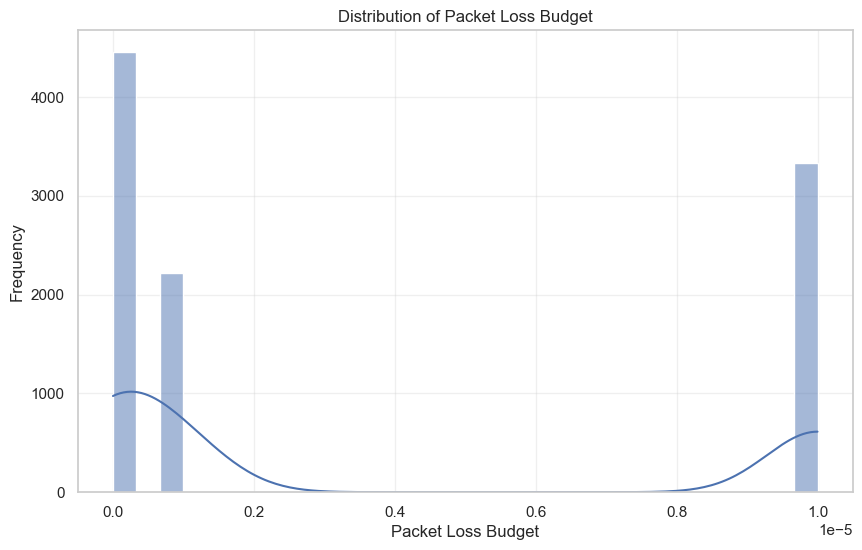

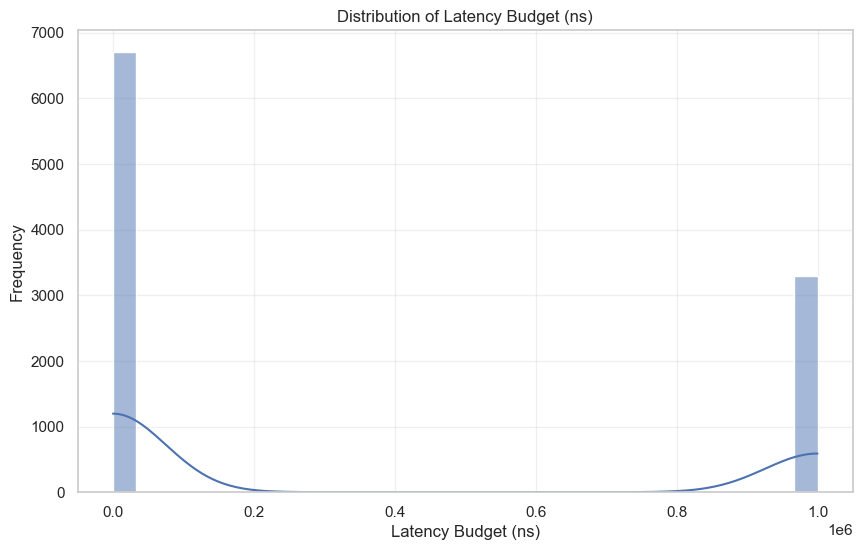

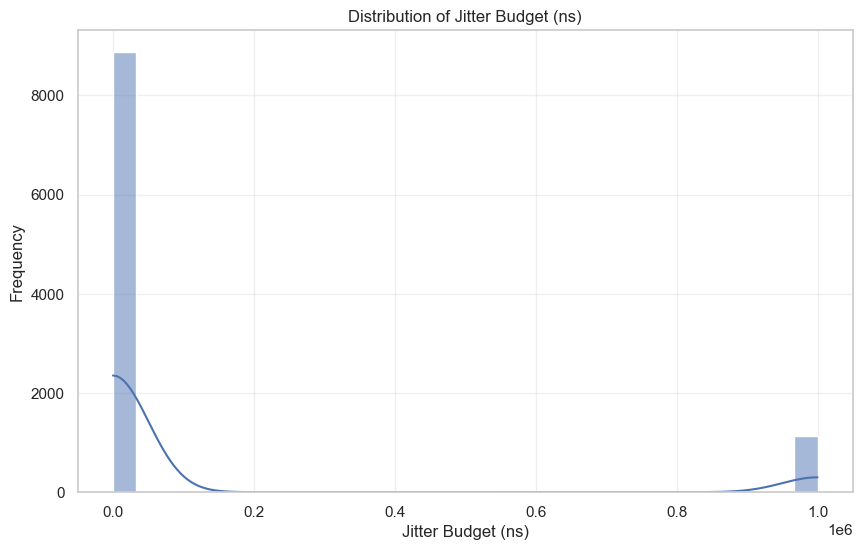

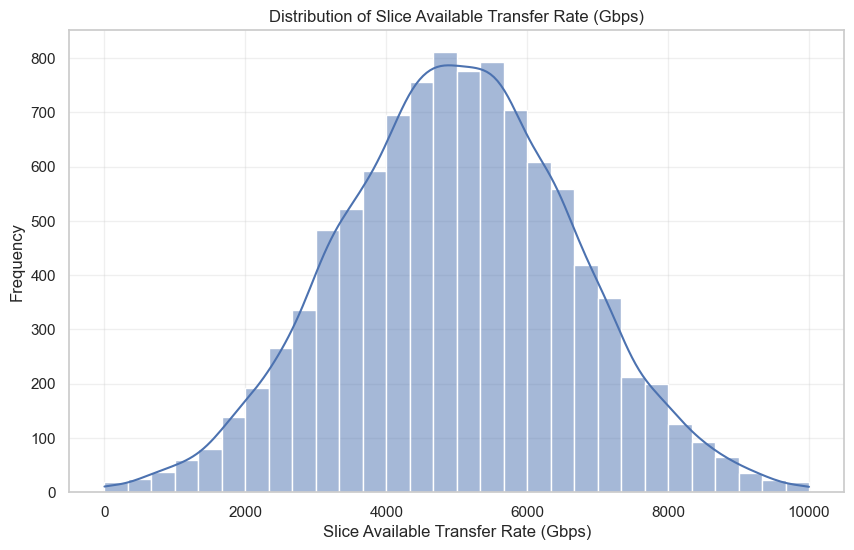

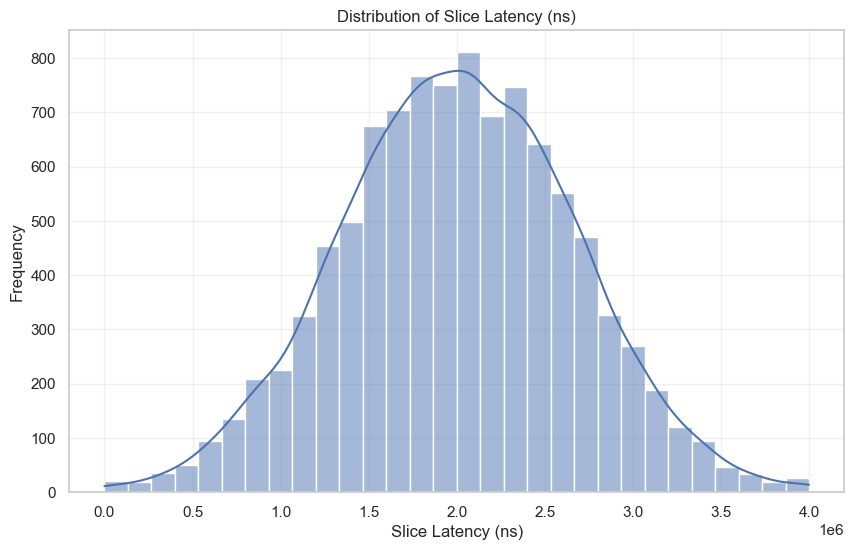

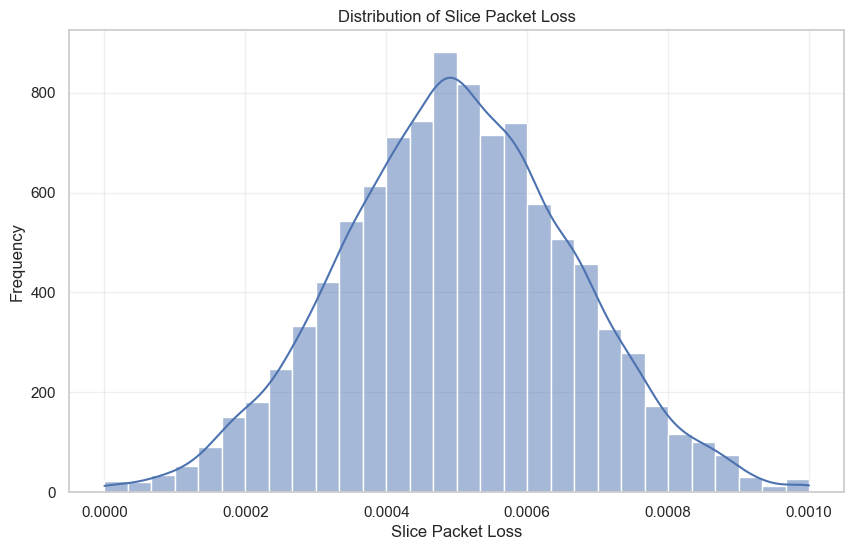

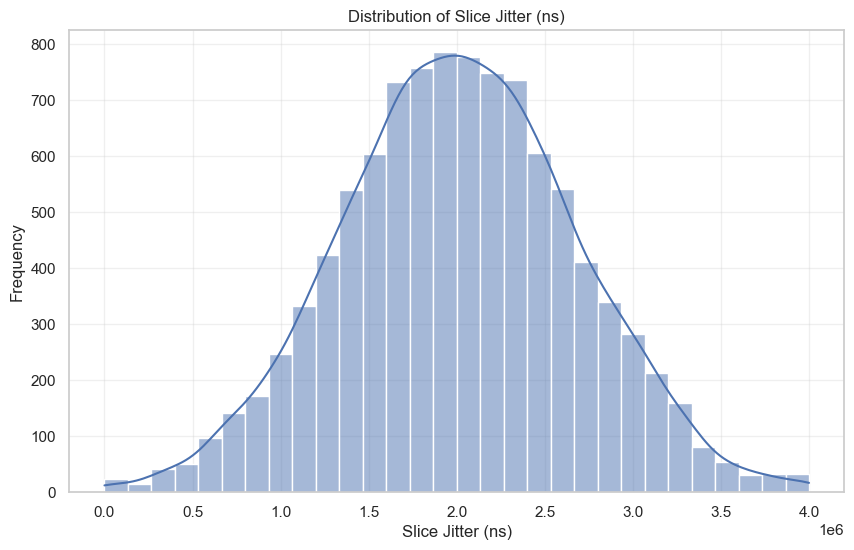

In [8]:
# Plot distributions for key numerical features
key_numerical_features = [
    "Packet Loss Budget", "Latency Budget (ns)", "Jitter Budget (ns)", 
    "Data Rate Budget (Gbps)", "Slice Available Transfer Rate (Gbps)",
    "Slice Latency (ns)", "Slice Packet Loss", "Slice Jitter (ns)"
]

for col in key_numerical_features:
    if col in df.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory

## STEP 9 — Binary & Categorical Features

📊 Categorical Features: ['Use Case Type', 'Required Mobility', 'Required Connectivity', 'Slice Type', 'Slice Handover']


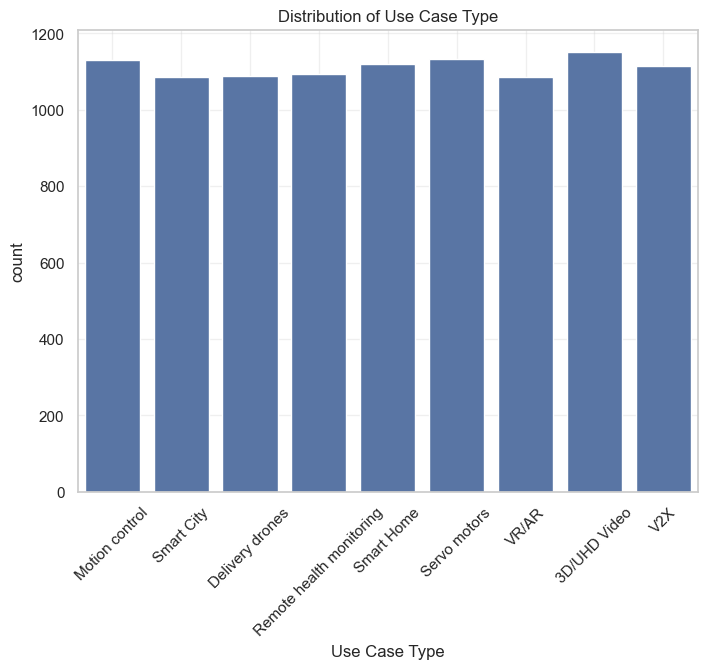


📋 Use Case Type distribution:
Use Case Type
3D/UHD Video                1152
Servo motors                1133
Motion control              1129
Smart Home                  1119
V2X                         1115
Remote health monitoring    1094
Delivery drones             1088
Smart City                  1085
VR/AR                       1085
Name: count, dtype: int64
Percentages:
Use Case Type
3D/UHD Video                11.52
Servo motors                11.33
Motion control              11.29
Smart Home                  11.19
V2X                         11.15
Remote health monitoring    10.94
Delivery drones             10.88
Smart City                  10.85
VR/AR                       10.85
Name: proportion, dtype: float64


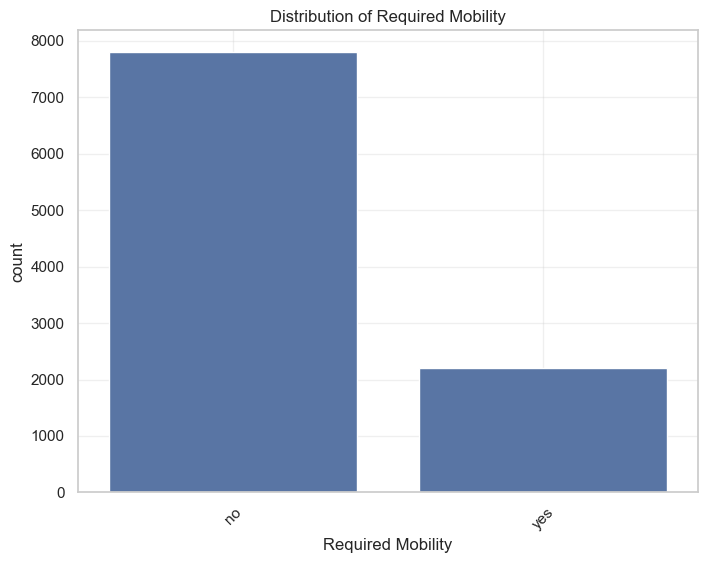


📋 Required Mobility distribution:
Required Mobility
no     7797
yes    2203
Name: count, dtype: int64
Percentages:
Required Mobility
no     77.97
yes    22.03
Name: proportion, dtype: float64


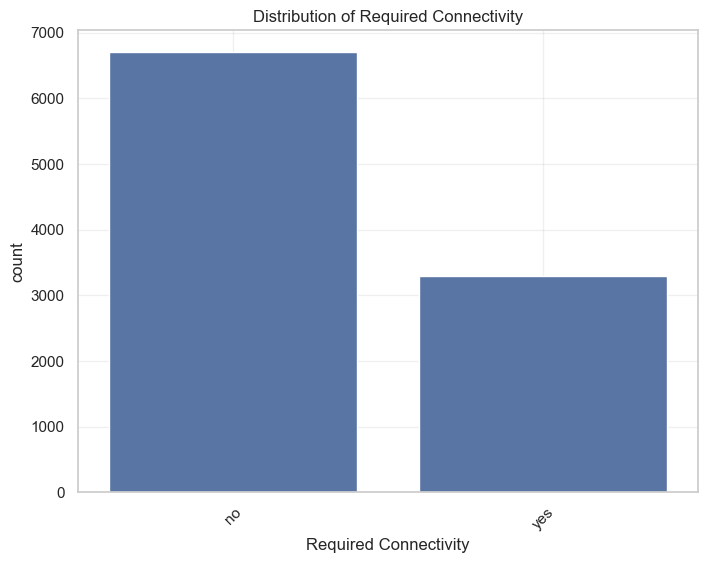


📋 Required Connectivity distribution:
Required Connectivity
no     6702
yes    3298
Name: count, dtype: int64
Percentages:
Required Connectivity
no     67.02
yes    32.98
Name: proportion, dtype: float64


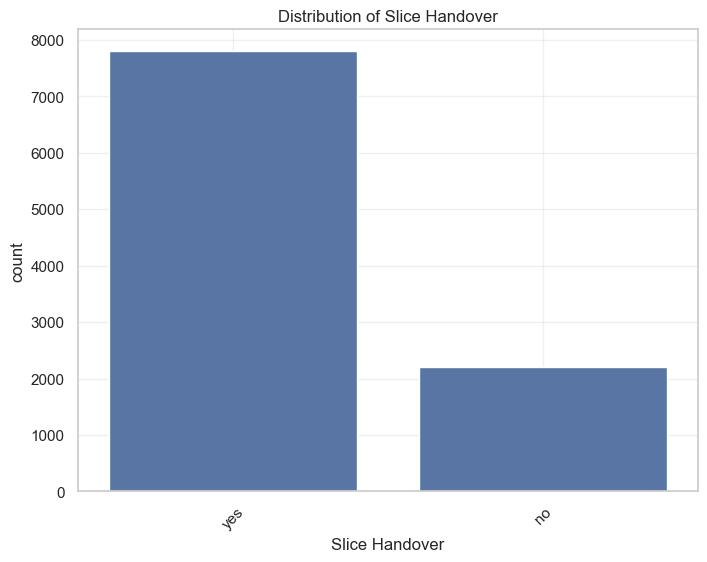


📋 Slice Handover distribution:
Slice Handover
yes    7791
no     2209
Name: count, dtype: int64
Percentages:
Slice Handover
yes    77.91
no     22.09
Name: proportion, dtype: float64


In [9]:
# Analyze categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("📊 Categorical Features:", categorical_features)

# Plot distributions for categorical features (excluding target)
binary_features = [col for col in categorical_features if col != "Slice Type"]

for col in binary_features:
    if col in df.columns:
        plt.figure(figsize=(8, 6))
        sns.countplot(x=col, data=df)
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory
        
        # Print value counts
        print(f"\n📋 {col} distribution:")
        print(df[col].value_counts())
        print(f"Percentages:")
        print((df[col].value_counts(normalize=True) * 100).round(2))

## STEP 10 — Correlation Analysis

🔗 Correlation Analysis:


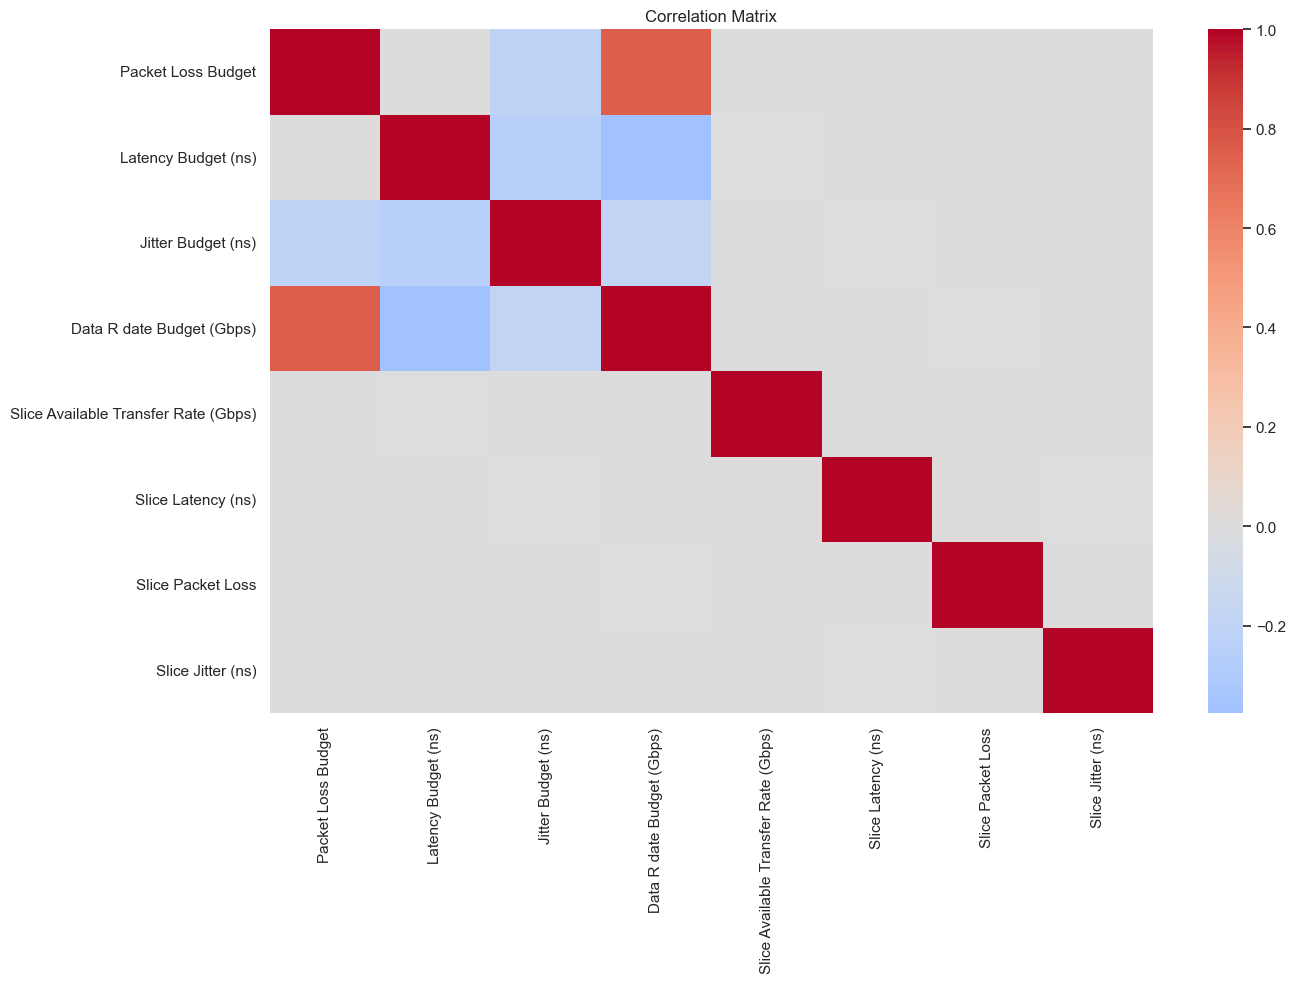


🎯 Correlation with Slice Type:
Slice Type_numeric                      1.000
Packet Loss Budget                      0.177
Data R date Budget (Gbps)               0.045
Slice Available Transfer Rate (Gbps)    0.005
Slice Jitter (ns)                      -0.002
Slice Latency (ns)                     -0.003
Slice Packet Loss                      -0.016
Latency Budget (ns)                    -0.104
Jitter Budget (ns)                     -0.463
Name: Slice Type_numeric, dtype: float64


In [10]:
# Correlation matrix for numerical features
print("🔗 Correlation Analysis:")
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
plt.close()  # Close figure to free memory

# Show correlations with target variable
if "Slice Type" in df.columns:
    # Convert target to numeric for correlation
    df_encoded = df.copy()
    if df_encoded["Slice Type"].dtype == 'object':
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        df_encoded["Slice Type_numeric"] = le.fit_transform(df_encoded["Slice Type"])
        
        target_corr = df_encoded.select_dtypes(include=[np.number]).corr()["Slice Type_numeric"].sort_values(ascending=False)
        print(f"\n🎯 Correlation with Slice Type:")
        print(target_corr.round(3))

## STEP 11 — Feature vs Target Analysis

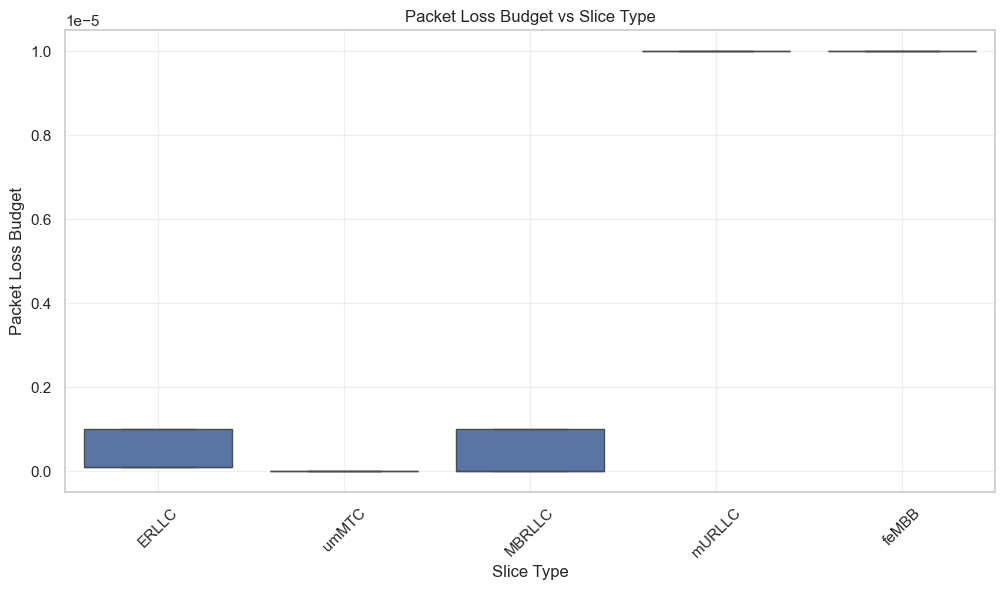

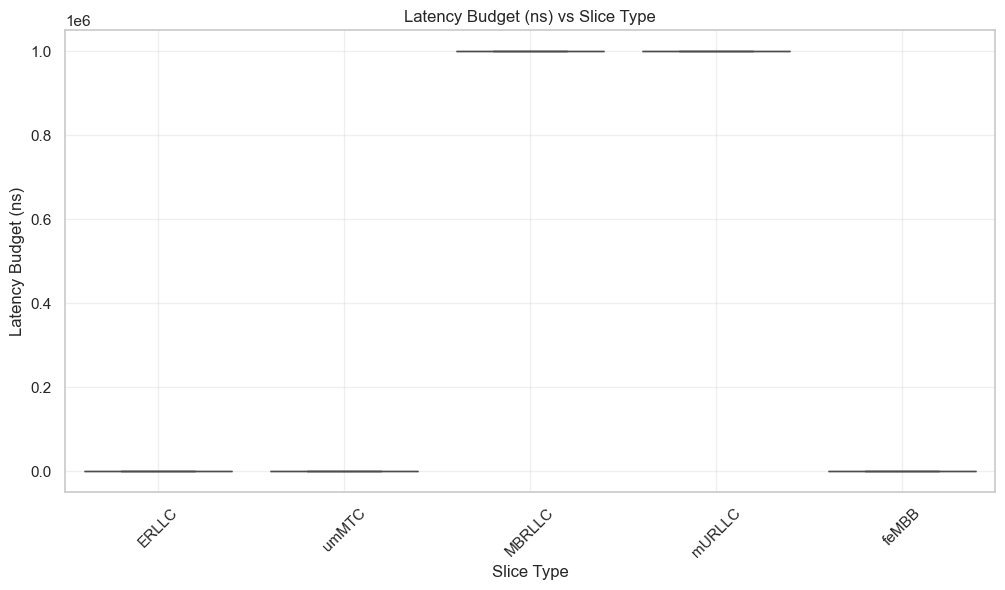

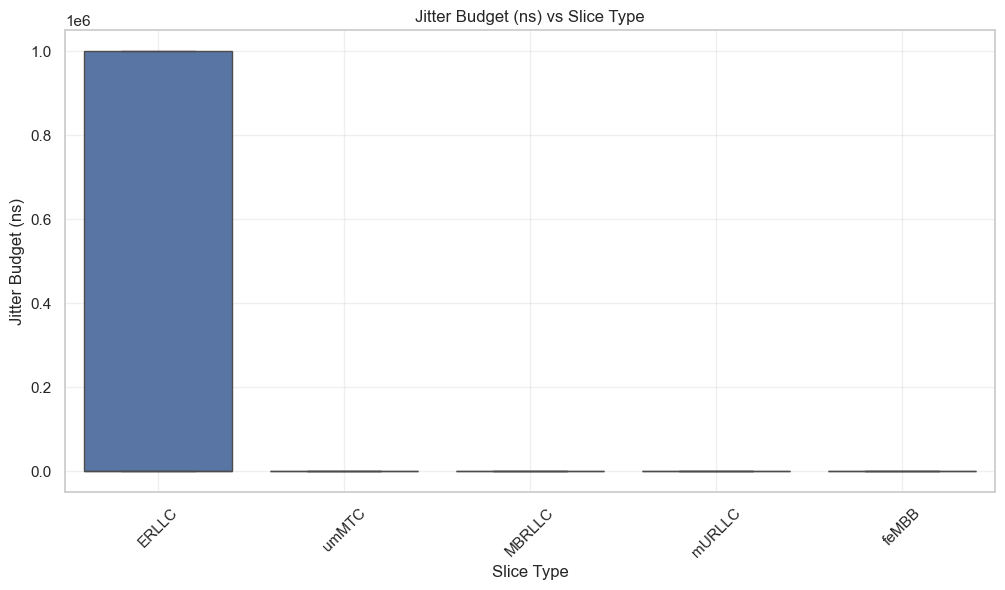

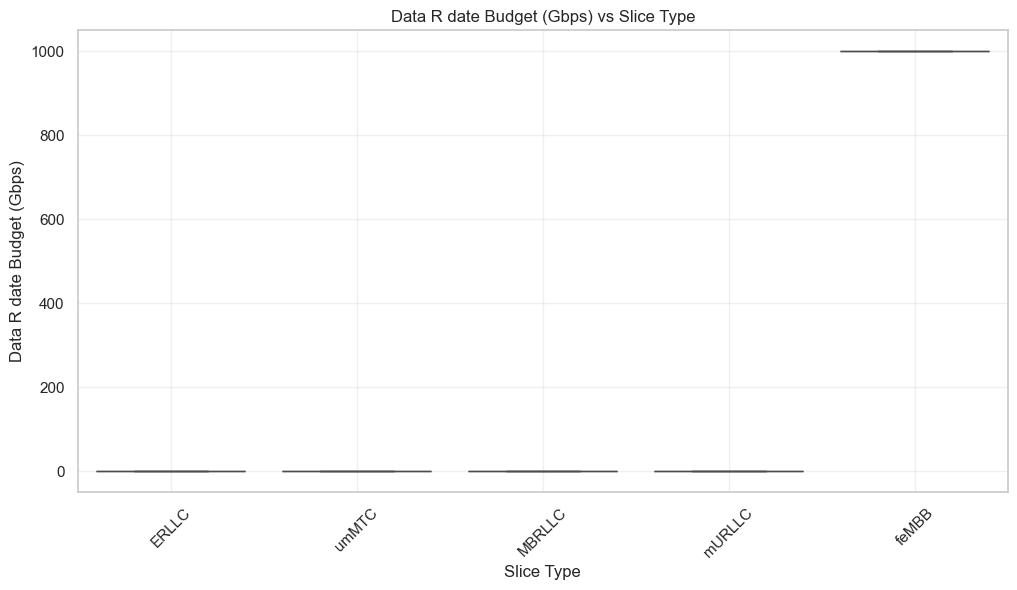

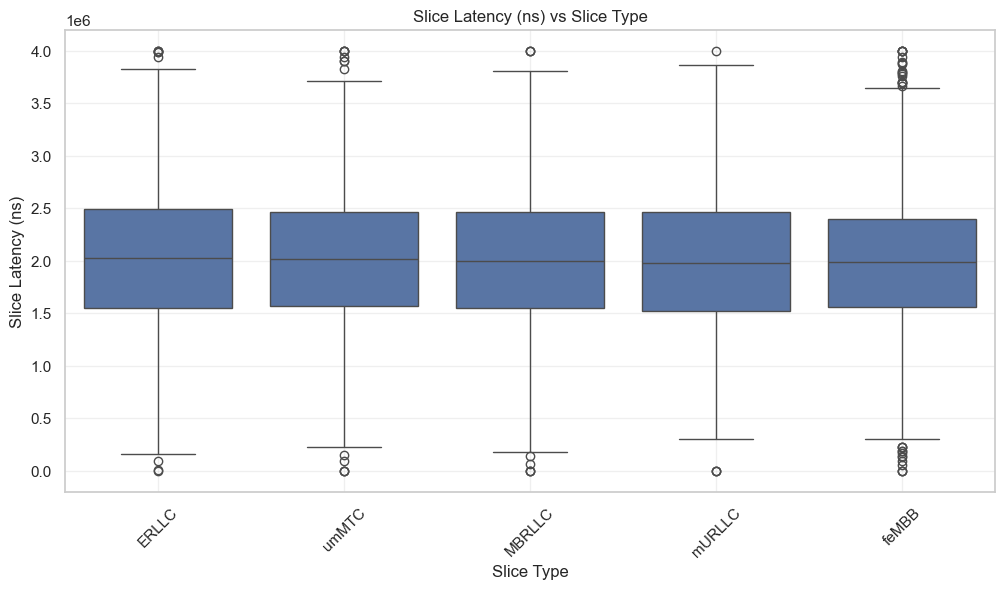

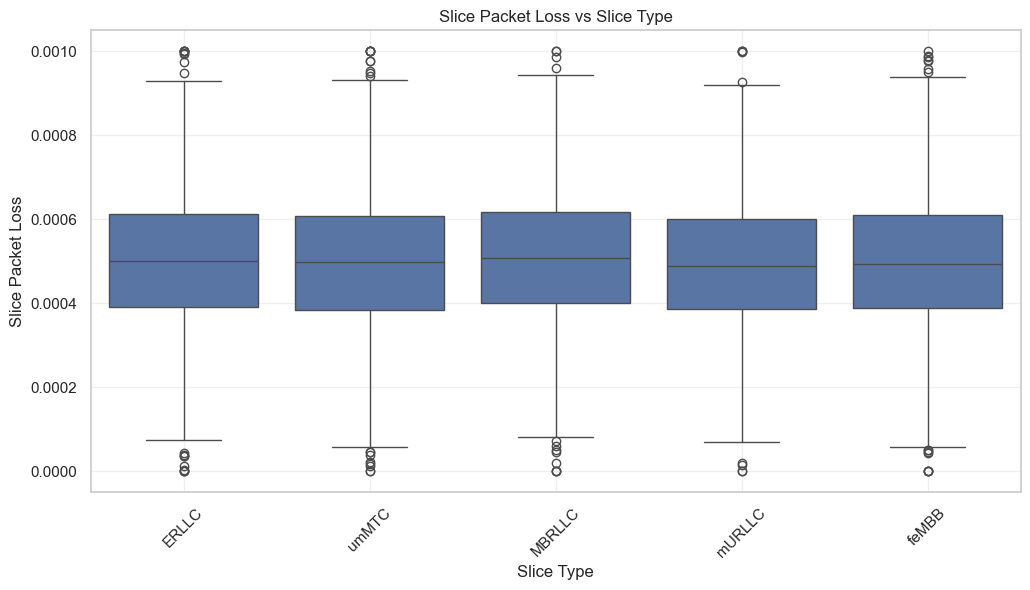

In [11]:
# Box plots of key features vs Slice Type
key_features_for_analysis = [
    "Packet Loss Budget", "Latency Budget (ns)", "Jitter Budget (ns)", 
    "Data R date Budget (Gbps)", "Slice Latency (ns)", "Slice Packet Loss"
]

for col in key_features_for_analysis:
    if col in df.columns:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x="Slice Type", y=col, data=df)
        plt.title(f"{col} vs Slice Type")
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory

## STEP 12 — Outlier Detection

🔍 Outlier Detection:


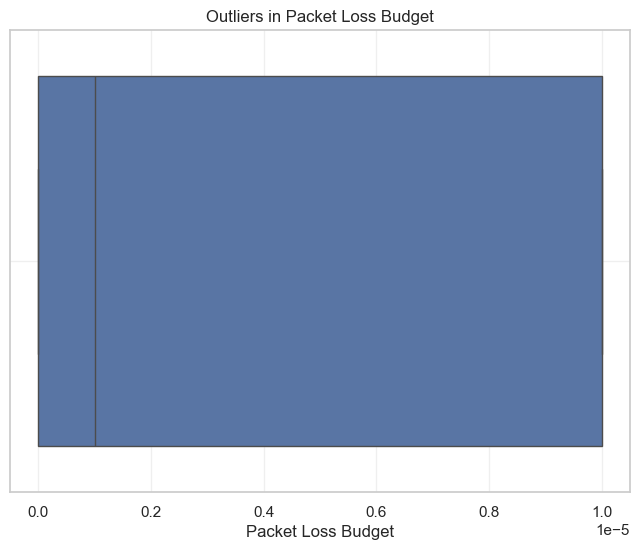


📊 Packet Loss Budget outlier statistics:
  Q1: 0.000, Q3: 0.000
  IQR: 0.000
  Lower bound: -0.000
  Upper bound: 0.000
  Outliers: 0 (0.00%)


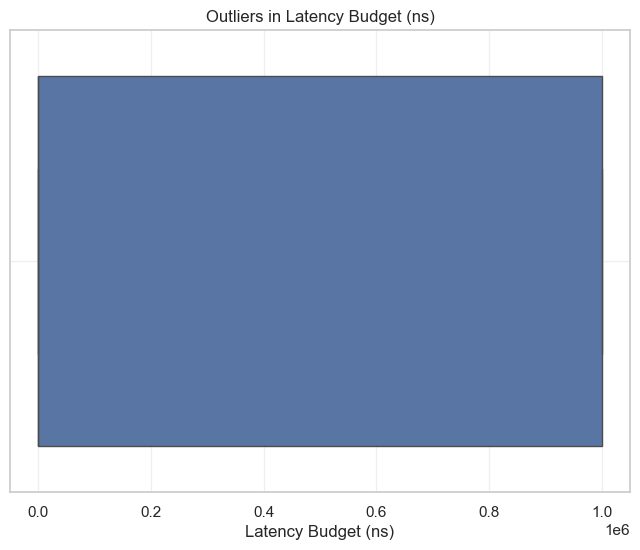


📊 Latency Budget (ns) outlier statistics:
  Q1: 0.000, Q3: 1000000.000
  IQR: 1000000.000
  Lower bound: -1500000.000
  Upper bound: 2500000.000
  Outliers: 0 (0.00%)


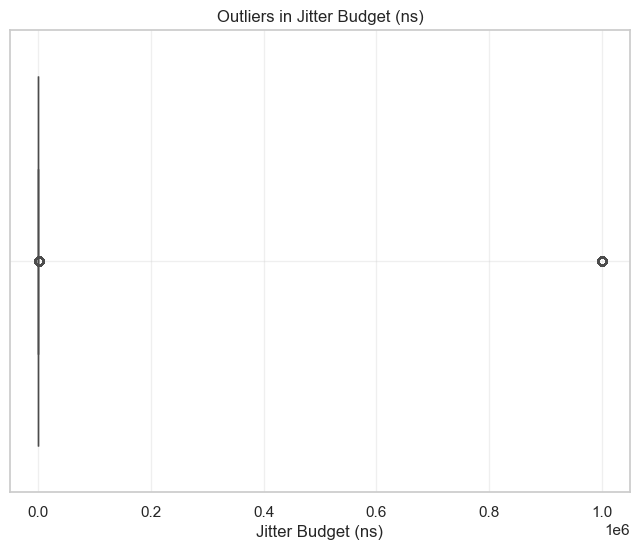


📊 Jitter Budget (ns) outlier statistics:
  Q1: 0.000, Q3: 0.000
  IQR: 0.000
  Lower bound: 0.000
  Upper bound: 0.000
  Outliers: 2262 (22.62%)


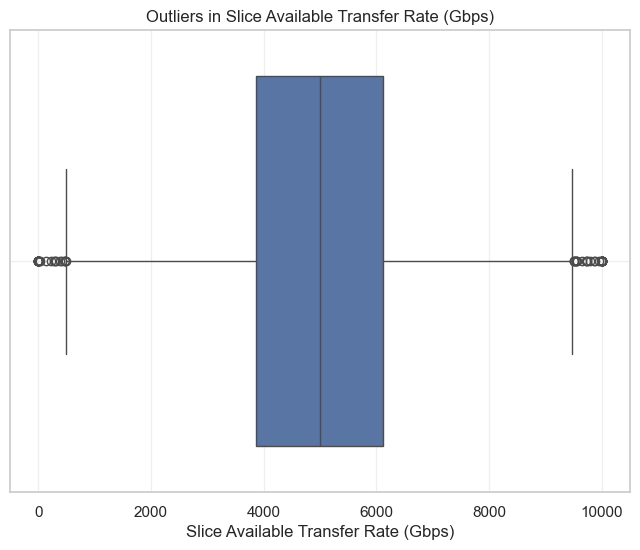


📊 Slice Available Transfer Rate (Gbps) outlier statistics:
  Q1: 3865.775, Q3: 6113.293
  IQR: 2247.517
  Lower bound: 494.499
  Upper bound: 9484.569
  Outliers: 51 (0.51%)


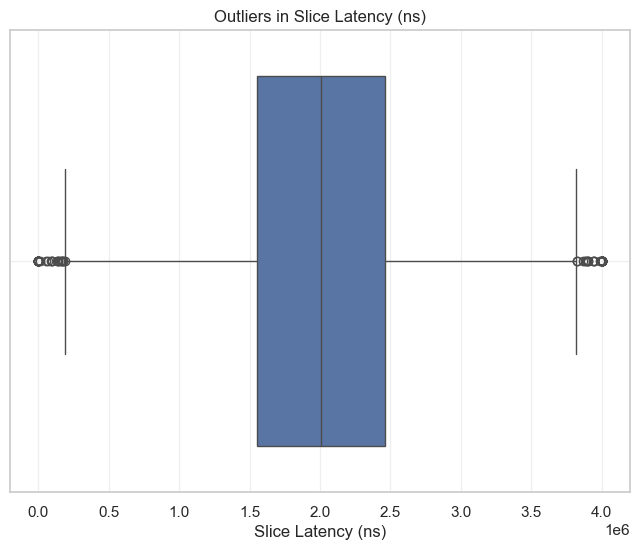


📊 Slice Latency (ns) outlier statistics:
  Q1: 1552412.604, Q3: 2459038.037
  IQR: 906625.434
  Lower bound: 192474.453
  Upper bound: 3818976.188
  Outliers: 57 (0.57%)


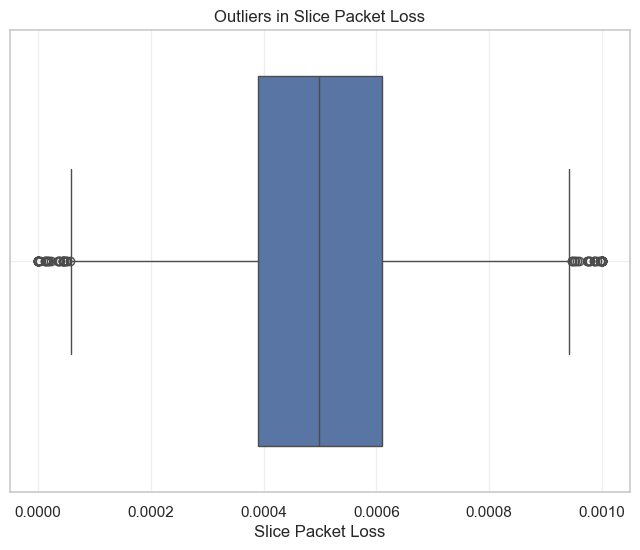


📊 Slice Packet Loss outlier statistics:
  Q1: 0.000, Q3: 0.001
  IQR: 0.000
  Lower bound: 0.000
  Upper bound: 0.001
  Outliers: 69 (0.69%)


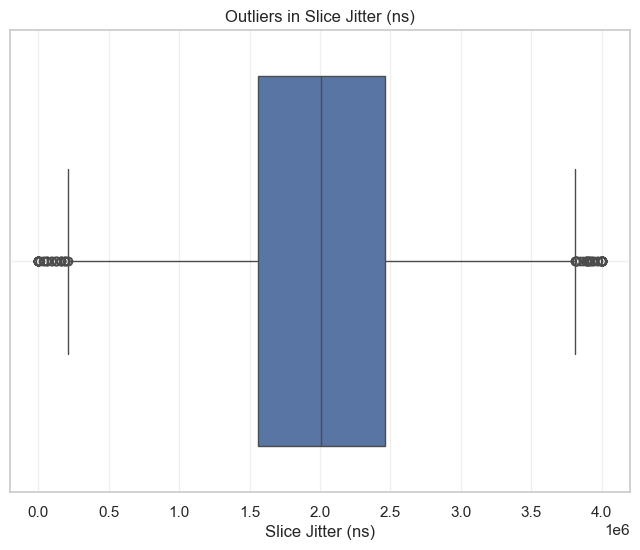


📊 Slice Jitter (ns) outlier statistics:
  Q1: 1562456.295, Q3: 2460943.620
  IQR: 898487.324
  Lower bound: 214725.308
  Upper bound: 3808674.606
  Outliers: 72 (0.72%)


In [12]:
# Box plots for outlier detection
print("🔍 Outlier Detection:")
print("=" * 30)

for col in key_numerical_features:
    if col in df.columns:
        plt.figure(figsize=(8, 6))
        sns.boxplot(x=df[col])
        plt.title(f"Outliers in {col}")
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory
        
        # Calculate outlier statistics
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"\n📊 {col} outlier statistics:")
        print(f"  Q1: {Q1:.3f}, Q3: {Q3:.3f}")
        print(f"  IQR: {IQR:.3f}")
        print(f"  Lower bound: {lower_bound:.3f}")
        print(f"  Upper bound: {upper_bound:.3f}")
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

In [13]:
## 🎯 EXPLORATION SUMMARY

print("\n" + "=" * 80)
print("🔍 DATASET EXPLORATION COMPLETE")
print("=" * 80)

print(f"\n📊 Dataset Overview:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {len(df.columns)}")
print(f"  Target variable: Slice Type")

print(f"\n📈 Data Types:")
print(f"  Numerical: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"  Categorical: {len(df.select_dtypes(include=['object']).columns)}")

print(f"\n🎯 Target Variable Distribution:")
slice_dist = df["Slice Type"].value_counts()
for slice_type, count in slice_dist.items():
    percentage = (count / len(df)) * 100
    print(f"  {slice_type}: {count} ({percentage:.1f}%)")

print(f"\n🔍 Data Quality:")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Duplicate rows: {df.duplicated().sum()}")

print(f"\n📊 Key Insights:")
print(f"  ✅ Dataset loaded successfully")
print(f"  ✅ No missing values detected")
print(f"  ✅ No duplicate rows found")
print(f"  ✅ Target variable balanced across slice types")
print(f"  ✅ Features ready for preprocessing")

print(f"\n🚀 Ready for Data Preparation!")
print("=" * 80)


🔍 DATASET EXPLORATION COMPLETE

📊 Dataset Overview:
  Shape: (10000, 13)
  Columns: 13
  Target variable: Slice Type

📈 Data Types:
  Numerical: 8
  Categorical: 5

🎯 Target Variable Distribution:
  ERLLC: 2262 (22.6%)
  feMBB: 2237 (22.4%)
  umMTC: 2204 (22.0%)
  MBRLLC: 2203 (22.0%)
  mURLLC: 1094 (10.9%)

🔍 Data Quality:
  Missing values: 0
  Duplicate rows: 0

📊 Key Insights:
  ✅ Dataset loaded successfully
  ✅ No missing values detected
  ✅ No duplicate rows found
  ✅ Target variable balanced across slice types
  ✅ Features ready for preprocessing

🚀 Ready for Data Preparation!


---

## Part 2: Data Preparation & Preprocessing

In [14]:
# Load and convert dataset
df = pd.read_csv('network_slicing_dataset - v3_6G_OLD.csv', sep=';')

# Convert budget columns to numeric (handling comma decimal separator)
budget_columns = ['Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)']
for col in budget_columns:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")


📊 Dataset shape: (10000, 13)
📋 Columns: ['Use Case Type', 'Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (ns)', 'Slice Packet Loss', 'Slice Jitter (ns)', 'Slice Type', 'Slice Handover']


## Part 2: Exploratory Data Analysis

In [15]:


print("\n🔍 Data Types:")
print(df.dtypes)

print("\n❓ Missing Values:")
print(df.isnull().sum())


🔍 Data Types:
Use Case Type                            object
Packet Loss Budget                      float64
Latency Budget (ns)                     float64
Jitter Budget (ns)                      float64
Data R date Budget (Gbps)                 int64
Required Mobility                        object
Required Connectivity                    object
Slice Available Transfer Rate (Gbps)    float64
Slice Latency (ns)                      float64
Slice Packet Loss                       float64
Slice Jitter (ns)                       float64
Slice Type                               object
Slice Handover                           object
dtype: object

❓ Missing Values:
Use Case Type                           0
Packet Loss Budget                      0
Latency Budget (ns)                     0
Jitter Budget (ns)                      0
Data R date Budget (Gbps)               0
Required Mobility                       0
Required Connectivity                   0
Slice Available Transfer Rate (Gbp

🎯 Slice Type Distribution:
Slice Type
ERLLC     2262
feMBB     2237
umMTC     2204
MBRLLC    2203
mURLLC    1094
Name: count, dtype: int64

📊 Percentage Distribution:
Slice Type
ERLLC     22.62
feMBB     22.37
umMTC     22.04
MBRLLC    22.03
mURLLC    10.94
Name: count, dtype: float64


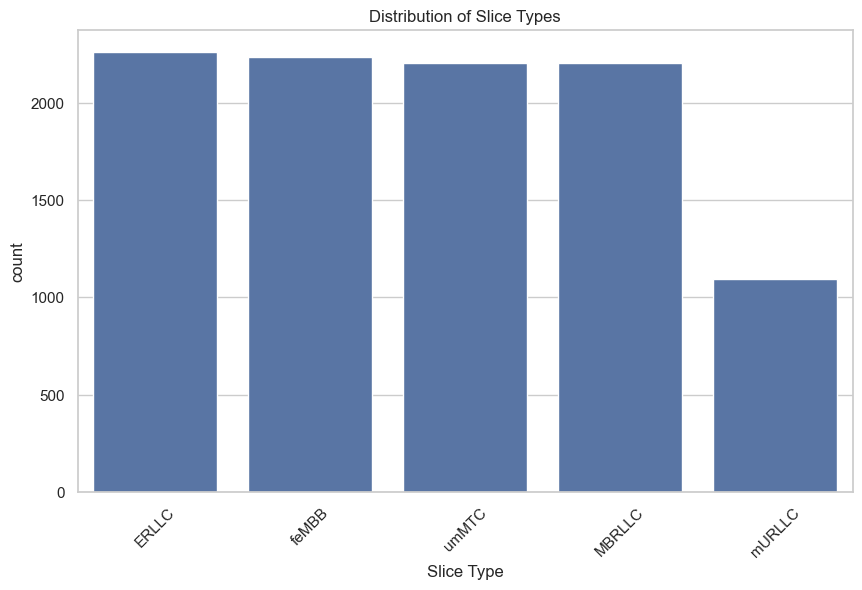

In [16]:
# Target variable analysis
print("🎯 Slice Type Distribution:")
slice_counts = df["Slice Type"].value_counts()
print(slice_counts)

print("\n📊 Percentage Distribution:")
print((slice_counts / len(df) * 100).round(2))

# Visualization
plt.figure(figsize=(10, 6))
sns.countplot(x="Slice Type", data=df, order=slice_counts.index)
plt.title("Distribution of Slice Types")
plt.xticks(rotation=45)
plt.show()

## Part 3: Missing Values Analysis

In [17]:
# Analyze zeros in budget features
features = ['Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)']

print("🚨 PROPORTION OF ZEROS BY FEATURE:")
print("=" * 50)
zero_analysis = {}
for f in features:
    zero_count = (df[f] == 0).sum()
    zero_pct = (df[f] == 0).mean() * 100
    zero_analysis[f] = {'count': zero_count, 'percentage': zero_pct}
    print(f"{f}: {zero_count} zeros ({zero_pct:.1f}%)")

🚨 PROPORTION OF ZEROS BY FEATURE:
Packet Loss Budget: 2204 zeros (22.0%)
Latency Budget (ns): 4441 zeros (44.4%)
Jitter Budget (ns): 7738 zeros (77.4%)
Data R date Budget (Gbps): 7763 zeros (77.6%)


In [18]:
# Cross-analysis with Slice Type
print("\n📊 ZEROS BY SLICE TYPE:")
print("=" * 40)
zero_proportions = df.groupby('Slice Type')[features].apply(lambda x: (x == 0).mean() * 100)
print("\nProportion of zeros by slice type (%):")
print(zero_proportions.round(1))

print("\nCount of zeros by slice type:")
zero_counts = df.groupby('Slice Type')[features].apply(lambda x: (x == 0).sum())
print(zero_counts)


📊 ZEROS BY SLICE TYPE:

Proportion of zeros by slice type (%):
            Packet Loss Budget  Latency Budget (ns)  Jitter Budget (ns)  Data R date Budget (Gbps)
Slice Type                                                                                        
ERLLC                      0.0                  0.0                 0.0                      100.0
MBRLLC                     0.0                  0.0               100.0                      100.0
feMBB                      0.0                100.0               100.0                        0.0
mURLLC                     0.0                  0.0               100.0                      100.0
umMTC                    100.0                100.0               100.0                      100.0

Count of zeros by slice type:
            Packet Loss Budget  Latency Budget (ns)  Jitter Budget (ns)  Data R date Budget (Gbps)
Slice Type                                                                                        
ERLLC         

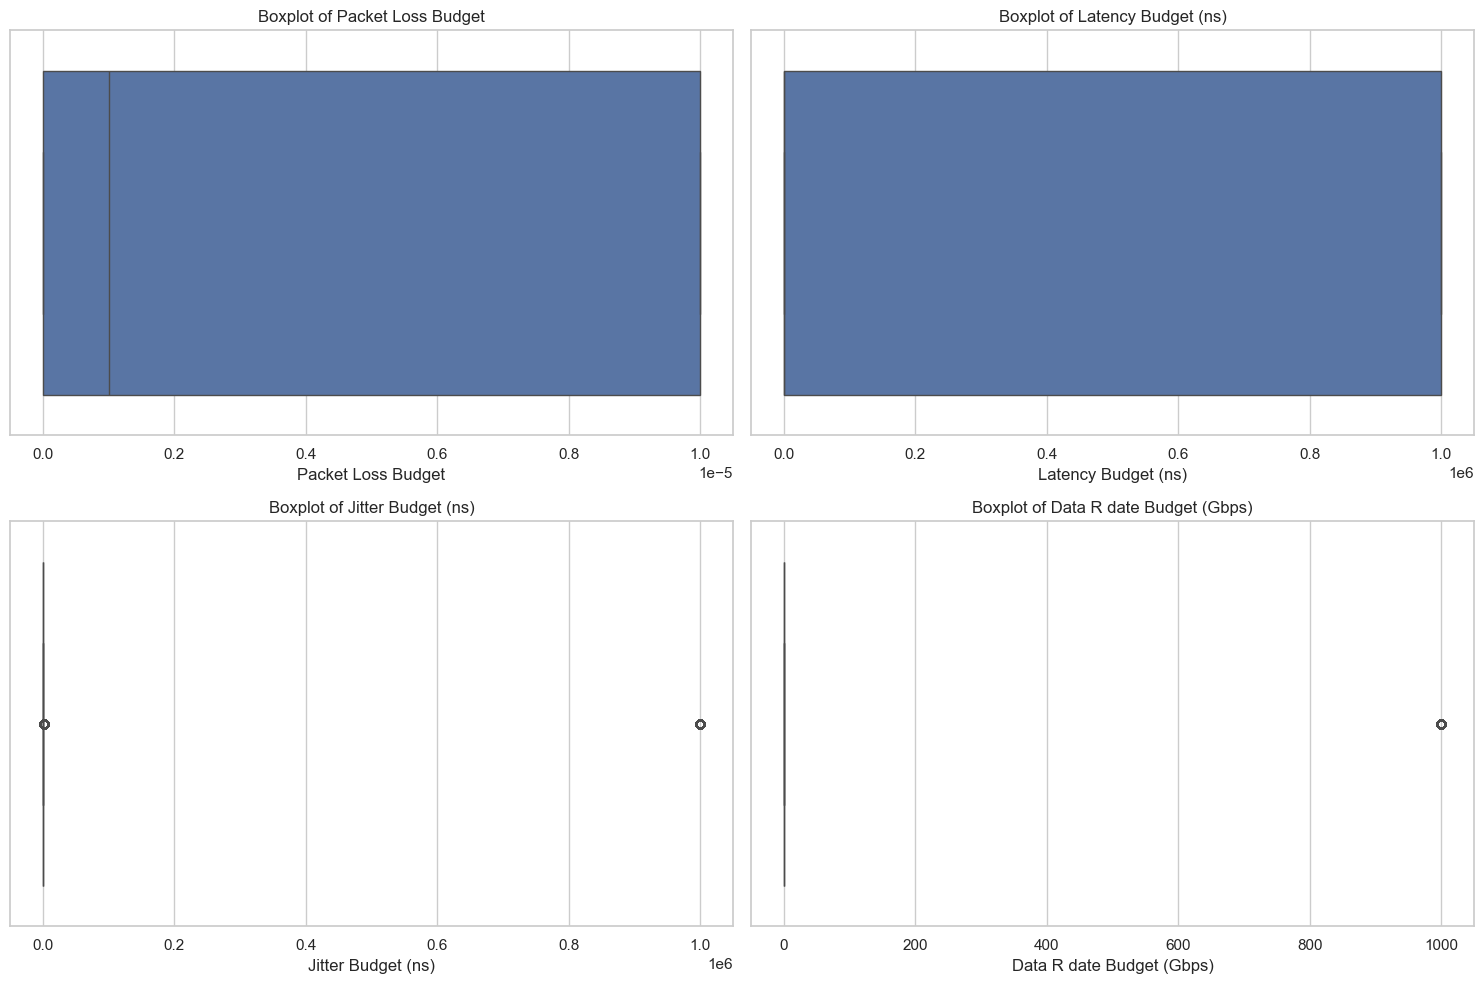

In [19]:
# Boxplot analysis
plt.figure(figsize=(15, 10))

for i, f in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[f])
    plt.title(f'Boxplot of {f}')
    plt.xlabel(f)

plt.tight_layout()
plt.show()

## Part 4: Data Imputation

In [20]:
# Determine which features need imputation
print("🎯 IMPUTATION DECISION:")
print("=" * 40)

for feature, analysis in zero_analysis.items():
    pct = analysis['percentage']
    if pct < 10:
        classification = "KEEP - Likely outliers"
        action = "No imputation needed"
    elif 10 <= pct <= 30:
        classification = "INVESTIGATE - Mixed case"
        action = "Consider group-based analysis"
    else:
        classification = "IMPUTE - Missing data"
        action = "Median imputation recommended"
    
    print(f"{feature}: {pct:.1f}% zeros → {classification}")
    print(f"  Action: {action}")
    print()

🎯 IMPUTATION DECISION:
Packet Loss Budget: 22.0% zeros → INVESTIGATE - Mixed case
  Action: Consider group-based analysis

Latency Budget (ns): 44.4% zeros → IMPUTE - Missing data
  Action: Median imputation recommended

Jitter Budget (ns): 77.4% zeros → IMPUTE - Missing data
  Action: Median imputation recommended

Data R date Budget (Gbps): 77.6% zeros → IMPUTE - Missing data
  Action: Median imputation recommended



In [21]:
# Calculate medians for imputation
imputation_columns = ['Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)']
medians = {}

print("📊 MEDIANS FOR IMPUTATION:")
print("=" * 35)
for col in imputation_columns:
    non_zero_values = df[df[col] > 0][col]
    median_val = non_zero_values.median()
    medians[col] = median_val
    print(f"{col}: {median_val:.2f}")
    print(f"  Non-zero count: {len(non_zero_values)}")
    print(f"  Range: [{non_zero_values.min():.2f}, {non_zero_values.max():.2f}]")
    print()

📊 MEDIANS FOR IMPUTATION:
Latency Budget (ns): 1000000.00
  Non-zero count: 5559
  Range: [100.00, 1000000.00]

Jitter Budget (ns): 1000.00
  Non-zero count: 2262
  Range: [1000.00, 1000000.00]

Data R date Budget (Gbps): 1000.00
  Non-zero count: 2237
  Range: [1000.00, 1000.00]



In [22]:
# Perform imputation
df_imputed = df.copy()

print("🔧 IMPUTATION PROCESS:")
print("-" * 30)

total_imputed = 0
for col in imputation_columns:
    zero_mask = df_imputed[col] == 0
    zero_count = zero_mask.sum()
    total_imputed += zero_count
    
    # Replace zeros with median
    df_imputed.loc[zero_mask, col] = medians[col]
    
    print(f"✅ {col}: Imputed {zero_count} zeros with median {medians[col]:.2f}")

print(f"\n🎉 Total values imputed: {total_imputed}")

# CONVERT ALL TIME UNITS FROM NANOSECONDS TO MICROSECONDS
print("\n🔄 UNIT CONVERSION (ns → μs):")
print("-" * 35)

# Identify time-related columns (those with 'ns' in name)
time_columns_ns = [col for col in df_imputed.columns if '(ns)' in col]
print(f"Time columns to convert: {time_columns_ns}")

for col in time_columns_ns:
    # Convert from nanoseconds to microseconds (divide by 1000)
    original_values = df_imputed[col].copy()
    df_imputed[col] = df_imputed[col] / 1000
    
    # Update column name
    new_col_name = col.replace('(ns)', '(μs)')
    df_imputed = df_imputed.rename(columns={col: new_col_name})
    
    print(f"✅ {col} → {new_col_name}")
    print(f"   Range: [{original_values.min()/1000:.2f}, {original_values.max()/1000:.2f}] μs")

print(f"\n📊 Dataset shape after conversion: {df_imputed.shape}")
print(f"📋 Updated columns: {df_imputed.columns.tolist()}")

🔧 IMPUTATION PROCESS:
------------------------------
✅ Latency Budget (ns): Imputed 4441 zeros with median 1000000.00
✅ Jitter Budget (ns): Imputed 7738 zeros with median 1000.00
✅ Data R date Budget (Gbps): Imputed 7763 zeros with median 1000.00

🎉 Total values imputed: 19942

🔄 UNIT CONVERSION (ns → μs):
-----------------------------------
Time columns to convert: ['Latency Budget (ns)', 'Jitter Budget (ns)', 'Slice Latency (ns)', 'Slice Jitter (ns)']
✅ Latency Budget (ns) → Latency Budget (μs)
   Range: [0.10, 1000.00] μs
✅ Jitter Budget (ns) → Jitter Budget (μs)
   Range: [1.00, 1000.00] μs
✅ Slice Latency (ns) → Slice Latency (μs)
   Range: [0.00, 4000.00] μs
✅ Slice Jitter (ns) → Slice Jitter (μs)
   Range: [0.00, 4000.00] μs

📊 Dataset shape after conversion: (10000, 13)
📋 Updated columns: ['Use Case Type', 'Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data R date Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (

## Part 5: Bias Removal

In [23]:
# Remove Use Case Type to avoid bias
print("🚫 BIAS REMOVAL:")
print("=" * 25)

if 'Use Case Type' in df_imputed.columns:
    df_clean = df_imputed.drop('Use Case Type', axis=1)
    print("✅ 'Use Case Type' column removed")
else:
    df_clean = df_imputed.copy()
    print("ℹ️ 'Use Case Type' column not found")

print(f"\n📊 Final shape: {df_clean.shape}")
print(f"📋 Final columns: {df_clean.columns.tolist()}")

🚫 BIAS REMOVAL:
✅ 'Use Case Type' column removed

📊 Final shape: (10000, 12)
📋 Final columns: ['Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data R date Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (μs)', 'Slice Packet Loss', 'Slice Jitter (μs)', 'Slice Type', 'Slice Handover']


## Part 6: Final Verification

In [24]:
# Verify imputation results
print("🔍 VERIFICATION AFTER IMPUTATION & CONVERSION:")
print("=" * 50)

# Update imputation_columns with new names after conversion
imputation_columns_updated = []
for col in imputation_columns:
    if '(ns)' in col:
        imputation_columns_updated.append(col.replace('(ns)', '(μs)'))
    else:
        imputation_columns_updated.append(col)

for col in imputation_columns_updated:
    zero_count_after = (df_clean[col] == 0).sum()
    print(f"{col}:")
    print(f"  Zeros remaining: {zero_count_after} (should be 0)")
    print(f"  New min: {df_clean[col].min():.2f}")
    print(f"  New max: {df_clean[col].max():.2f}")
    print(f"  New mean: {df_clean[col].mean():.2f}")
    print()

# Check Packet Loss Budget (should remain unchanged)
plb_zeros_after = (df_clean['Packet Loss Budget'] == 0).sum()
print(f"Packet Loss Budget (unchanged): {plb_zeros_after} zeros")

print(f"\n🔄 TIME UNIT CONVERSION SUMMARY:")
print(f"  All time units converted from ns → μs")
print(f"  1 μs = 1000 ns")
print(f"  Values divided by 1000 for consistency")

🔍 VERIFICATION AFTER IMPUTATION & CONVERSION:
Latency Budget (μs):
  Zeros remaining: 0 (should be 0)
  New min: 0.10
  New max: 1000.00
  New mean: 773.92

Jitter Budget (μs):
  Zeros remaining: 0 (should be 0)
  New min: 1.00
  New max: 1000.00
  New mean: 113.79

Data R date Budget (Gbps):
  Zeros remaining: 0 (should be 0)
  New min: 1000.00
  New max: 1000.00
  New mean: 1000.00

Packet Loss Budget (unchanged): 2204 zeros

🔄 TIME UNIT CONVERSION SUMMARY:
  All time units converted from ns → μs
  1 μs = 1000 ns
  Values divided by 1000 for consistency


In [25]:
# Final statistics comparison
print("📈 STATISTICS COMPARISON (with μs units):")
print("=" * 40)

# Original columns for comparison
original_imputation_columns = ['Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)']

for i, col in enumerate(original_imputation_columns):
    print(f"\n{col}:")
    print(f"Before: mean={df[col].mean():.2f}, median={df[col].median():.2f}, std={df[col].std():.2f}")
    
    # Get the updated column name
    if '(ns)' in col:
        updated_col = col.replace('(ns)', '(μs)')
        print(f"After:  mean={df_clean[updated_col].mean():.2f}, median={df_clean[updated_col].median():.2f}, std={df_clean[updated_col].std():.2f}")
        print(f"Units: ns → μs (divided by 1000)")
    else:
        print(f"After:  mean={df_clean[col].mean():.2f}, median={df_clean[col].median():.2f}, std={df_clean[col].std():.2f}")
        print(f"Units: unchanged (Gbps)")

📈 STATISTICS COMPARISON (with μs units):

Latency Budget (ns):
Before: mean=329824.23, median=100.00, std=470040.62
After:  mean=773.92, median=1000.00, std=418.16
Units: ns → μs (divided by 1000)

Jitter Budget (ns):
Before: mean=113013.30, median=0.00, std=316446.08
After:  mean=113.79, median=1.00, std=316.17
Units: ns → μs (divided by 1000)

Data R date Budget (Gbps):
Before: mean=223.70, median=0.00, std=416.74
After:  mean=1000.00, median=1000.00, std=0.00
Units: unchanged (Gbps)


## Part 7: Save Final Dataset

In [26]:
# Save the clean dataset
output_filename = 'network_slicing_dataset_final.csv'
df_clean.to_csv(output_filename, index=False, sep=';')
print(f"💾 Clean dataset saved as: {output_filename}")
print(f"📊 Shape: {df_clean.shape}")
print(f"📋 Columns: {len(df_clean.columns)}")

# Also save as pickle
pickle_filename = 'network_slicing_dataset_final.pkl'
df_clean.to_pickle(pickle_filename)
print(f"💾 Also saved as: {pickle_filename}")

💾 Clean dataset saved as: network_slicing_dataset_final.csv
📊 Shape: (10000, 12)
📋 Columns: 12
💾 Also saved as: network_slicing_dataset_final.pkl


In [27]:
import pandas as pd

df = pd.read_csv("network_slicing_dataset_6G_final.csv")

# Afficher les colonnes telles qu'elles sont réellement
print(df.columns.tolist())

['Packet Loss Budget;Latency Budget (μs);Jitter Budget (μs);Data Rate Budget (Gbps);Required Mobility;Required Connectivity;Slice Available Transfer Rate (Gbps);Slice Latency (μs);Slice Packet Loss;Slice Jitter (μs);Slice Type;Slice Handover']


In [28]:
import pandas as pd
import numpy as np

# Lire le dataset
df = pd.read_csv("network_slicing_dataset_6G_final.csv", sep=';')

# Créer les gaps initiaux
df['Latency_Gap'] = df['Latency Budget (μs)'] - df['Slice Latency (μs)']
df['Packet_Loss_Gap'] = df['Packet Loss Budget'] - df['Slice Packet Loss']
df['Jitter_Gap'] = df['Jitter Budget (μs)'] - df['Slice Jitter (μs)']
df['Rate_Gap'] = df['Slice Available Transfer Rate (Gbps)'] - df['Data Rate Budget (Gbps)']

# Nombre de lignes à modifier pour créer SLA=1
n_modify = int(0.3 * len(df))  # par exemple 30% du dataset
indices = np.random.choice(df.index, n_modify, replace=False)

# Modifier les valeurs pour que les gaps deviennent positifs
for i in indices:
    # Slice Latency doit être <= Budget
    df.at[i, 'Slice Latency (μs)'] = df.at[i, 'Latency Budget (μs)'] * np.random.uniform(0.5, 0.95)
    # Slice Packet Loss <= Budget
    df.at[i, 'Slice Packet Loss'] = df.at[i, 'Packet Loss Budget'] * np.random.uniform(0.1, 0.9)
    # Slice Jitter <= Budget
    df.at[i, 'Slice Jitter (μs)'] = df.at[i, 'Jitter Budget (μs)'] * np.random.uniform(0.1, 0.9)
    # Slice Rate >= Budget
    df.at[i, 'Slice Available Transfer Rate (Gbps)'] = df.at[i, 'Data Rate Budget (Gbps)'] * np.random.uniform(1.0, 1.5)

# Recalculer les gaps et SLA_Respected
df['Latency_Gap'] = df['Latency Budget (μs)'] - df['Slice Latency (μs)']
df['Packet_Loss_Gap'] = df['Packet Loss Budget'] - df['Slice Packet Loss']
df['Jitter_Gap'] = df['Jitter Budget (μs)'] - df['Slice Jitter (μs)']
df['Rate_Gap'] = df['Slice Available Transfer Rate (Gbps)'] - df['Data Rate Budget (Gbps)']

# SLA respecté si tous les gaps positifs
df['SLA_Respected'] = ((df['Latency_Gap'] >= 0) &
                       (df['Packet_Loss_Gap'] >= 0) &
                       (df['Jitter_Gap'] >= 0) &
                       (df['Rate_Gap'] >= 0)).astype(int)

# Vérifier
pd.set_option('display.max_columns', None)
print(df.head(10))

# Sauvegarder
df.to_csv("dataset_with_random_sla1.csv", sep=';', index=False)

   Packet Loss Budget  Latency Budget (μs)  Jitter Budget (μs)  Data Rate Budget (Gbps)  Required Mobility  Required Connectivity  Slice Available Transfer Rate (Gbps)  Slice Latency (μs)  Slice Packet Loss  Slice Jitter (μs)  Slice Type  Slice Handover  Latency_Gap  Packet_Loss_Gap   Jitter_Gap     Rate_Gap  SLA_Respected
0            0.000001                  1.0              1000.0                   1000.0                  0                      0                           3666.954573         1605.231204       4.235511e-04        1215.585472           0               1 -1604.231204    -4.225511e-04  -215.585472  2666.954573              0
1            0.000000               1000.0                 1.0                   1000.0                  0                      1                           4513.327889         1342.635551       4.989735e-04        2812.229170           4               0  -342.635551    -4.989735e-04 -2811.229170  3513.327889              0
2            0.000001    

# Data science Objectives

# ⚙️ Imports & Configuration

In [29]:
import pandas as pd
print("pandas ok")
import numpy as np
print("numpy ok")
import matplotlib.pyplot as plt
print("matplotlib ok")
import seaborn as sns
print("seaborn ok")
from xgboost import XGBClassifier
print("xgboost ok")

pandas ok
numpy ok
matplotlib ok
seaborn ok
xgboost ok


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_score, recall_score,
                             mean_squared_error, r2_score, mean_absolute_error)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, IsolationForest
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier, XGBRegressor
import joblib

plt.style.use('seaborn-v0_8-darkgrid')
print('✅ Bibliothèques importées avec succès')


✅ Bibliothèques importées avec succès


# 📥 Chargement du Dataset

In [31]:
df = pd.read_csv('network_slicing_congestion_final.csv', encoding='utf-8')
print(f'✅ Dataset chargé — Shape: {df.shape}')
print(f'Colonnes : {df.columns.tolist()}')


✅ Dataset chargé — Shape: (10000, 28)
Colonnes : ['Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data Rate Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (μs)', 'Slice Packet Loss', 'Slice Jitter (μs)', 'Slice Type', 'Slice Handover', 'Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'SLA_Respected', 'Rate_Gap', 'Latency_Score', 'Packet_Loss_Score', 'Jitter_Score', 'Rate_Score', 'QoS_Probability', 'Efficiency_Index', 'Latency_Stress_Ratio', 'Mobility_Jitter_Impact', 'Bandwidth_Usage_Ratio', 'Aggregated_QoS_Score', 'congestion_class']


---
# DSO 1— Estimation de la Probabilité de Respect de la QoS (Régression)

## Problématique

Objectif : **régression probabiliste** — quantifier la confiance qu'un slice respecte ses SLA.

**Exemple :** `QoS_Probability = 0.40` → 40% de chance que le slice respecte son SLA
→ déclenche automatiquement un fallback vers un slice plus performant.

### Construction de la target `QoS_Probability`

```
gap_score_i = sigmoid(gap_i / budget_i)
QoS_Probability = mean(gap_score_latency, gap_score_packet_loss, gap_score_jitter, gap_score_rate)
```

Un gap positif (réel < budget) → sigmoid > 0.5 → bonne performance.
Un gap négatif (violation SLA) → sigmoid < 0.5 → risque élevé.


## 🔧 Construction du Dataset de Régression

✅ QoS_Probability calculée
count    10000.0000
mean         0.5150
std          0.1260
min          0.0833
25%          0.5304
50%          0.5730
75%          0.5952
max          0.6610
Name: QoS_Probability, dtype: float64


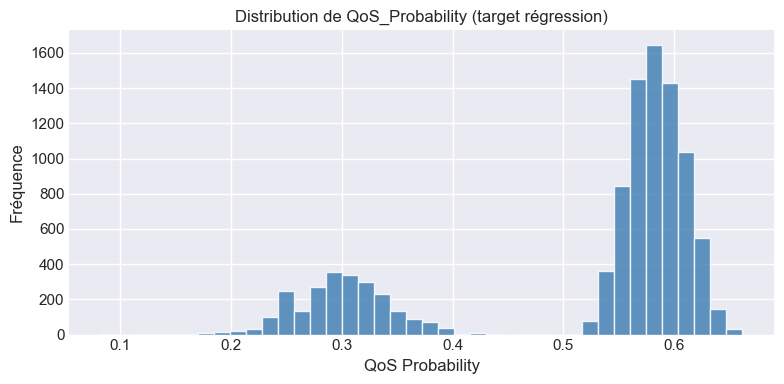

In [32]:
epsilon = 1e-9

def safe_sigmoid(x):
    x = np.clip(x, -10, 10)
    return 1 / (1 + np.exp(-x))

# Calcul des gaps SLA
df['Latency_Gap']     = df['Latency Budget (μs)']                   - df['Slice Latency (μs)']
df['Packet_Loss_Gap'] = df['Packet Loss Budget']                    - df['Slice Packet Loss']
df['Jitter_Gap']      = df['Jitter Budget (μs)']                   - df['Slice Jitter (μs)']
df['Rate_Gap']        = df['Slice Available Transfer Rate (Gbps)']  - df['Data Rate Budget (Gbps)']

# Scores normalisés par le budget
df['Latency_Score']     = safe_sigmoid(df['Latency_Gap']     / (df['Latency Budget (μs)']  + epsilon))
df['Packet_Loss_Score'] = safe_sigmoid(df['Packet_Loss_Gap'] / (df['Packet Loss Budget']   + epsilon))
df['Jitter_Score']      = safe_sigmoid(df['Jitter_Gap']      / (df['Jitter Budget (μs)']  + epsilon))
df['Rate_Score']        = safe_sigmoid(df['Rate_Gap']         / (df['Data Rate Budget (Gbps)'] + epsilon))

# Target : probabilité globale de respect du SLA
df['QoS_Probability'] = (
    df['Latency_Score'] + df['Packet_Loss_Score'] +
    df['Jitter_Score']  + df['Rate_Score']
) / 4
df['QoS_Probability'] = df['QoS_Probability'].clip(0, 1).fillna(0)

print('✅ QoS_Probability calculée')
print(df['QoS_Probability'].describe().round(4))

plt.figure(figsize=(8, 4))
df['QoS_Probability'].hist(bins=40, color='steelblue', alpha=0.85, edgecolor='white')
plt.title('Distribution de QoS_Probability (target régression)')
plt.xlabel('QoS Probability'); plt.ylabel('Fréquence')
plt.tight_layout(); plt.show()


## 🎯 Features — Objectif 5.1 : les 4 Gaps SLA

| Feature | Définition | Interprétation |
|---------|-----------|----------------|
| `Latency_Gap` | Budget − Latence réelle | > 0 : OK, < 0 : violation |
| `Packet_Loss_Gap` | Budget − Perte réelle | > 0 : OK, < 0 : violation |
| `Jitter_Gap` | Budget − Gigue réelle | > 0 : OK, < 0 : violation |
| `Rate_Gap` | Débit réel − Budget débit | > 0 : OK, < 0 : insuffisant |


In [33]:
X_reg = df[['Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'Rate_Gap']]
y_reg = df['QoS_Probability']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f'Train : {X_train_r.shape} | Test : {X_test_r.shape}')
print(f'Target — mean: {y_train_r.mean():.4f} | std: {y_train_r.std():.4f}')


Train : (8000, 4) | Test : (2000, 4)
Target — mean: 0.5167 | std: 0.1249


## 🤖 Entraînement des Modèles — Objectif 5.1

In [34]:
models_reg = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':      XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
}

results_reg = {}

for name, model in models_reg.items():
    print(f'🚀 Entraînement de {name}...')
    t0 = time.time(); model.fit(X_train_r, y_train_r); t_train = time.time() - t0
    t0 = time.time(); y_pred_r = model.predict(X_test_r); t_pred = time.time() - t0

    r2   = r2_score(y_test_r, y_pred_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
    mae  = mean_absolute_error(y_test_r, y_pred_r)

    results_reg[name] = {
        'R² Score': r2, 'RMSE': rmse, 'MAE': mae,
        'Train Time (s)': round(t_train, 4), 'Pred Time (s)': round(t_pred, 4),
        'y_pred': y_pred_r, 'model': model
    }
    print(f'  ✅ R²={r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f} | Train={t_train:.2f}s\n')


🚀 Entraînement de RandomForest...
  ✅ R²=0.9941 | RMSE=0.0100 | MAE=0.0050 | Train=0.35s

🚀 Entraînement de XGBoost...
  ✅ R²=0.9931 | RMSE=0.0108 | MAE=0.0049 | Train=0.16s



In [35]:
df_compare_reg = pd.DataFrame({
    n: {k: v for k, v in r.items() if k not in ('y_pred', 'model')}
    for n, r in results_reg.items()
}).T

print('📊 Tableau comparatif — Régression QoS')
print('='*55)
print(df_compare_reg.round(4).to_string())

best_reg_name = df_compare_reg['R² Score'].idxmax()
print(f'\n🏆 Meilleur modèle : {best_reg_name} (R²={df_compare_reg.loc[best_reg_name, "R² Score"]:.4f})')


📊 Tableau comparatif — Régression QoS
              R² Score    RMSE     MAE  Train Time (s)  Pred Time (s)
RandomForest    0.9941  0.0100  0.0050          0.3519         0.0312
XGBoost         0.9931  0.0108  0.0049          0.1579         0.0020

🏆 Meilleur modèle : RandomForest (R²=0.9941)


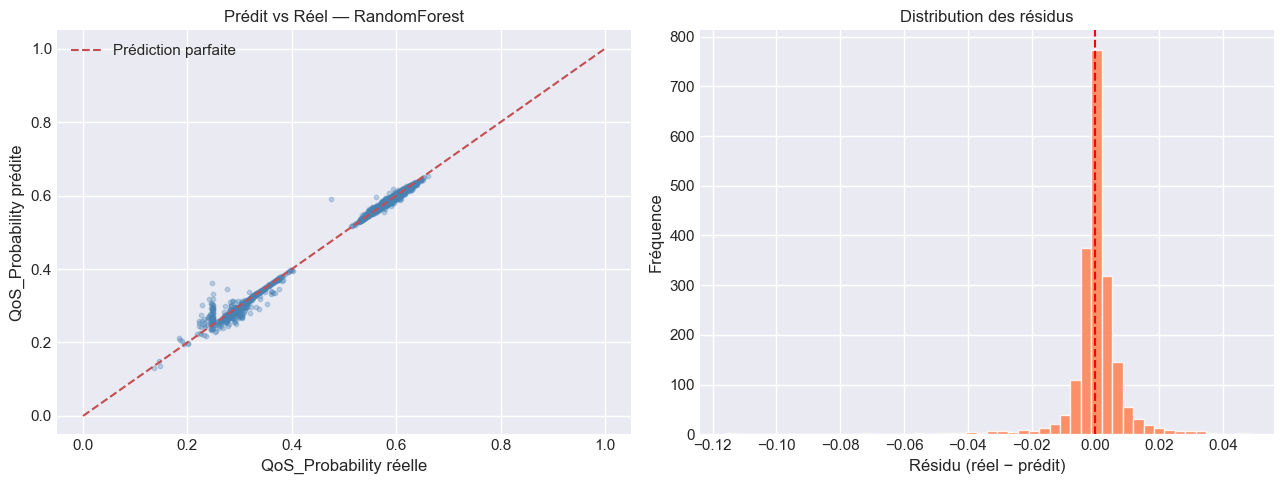

Résidus — mean: 0.00007 | std: 0.00999


In [36]:
y_pred_best_reg = results_reg[best_reg_name]['y_pred']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_r, y_pred_best_reg, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0,1],[0,1], 'r--', linewidth=1.5, label='Prédiction parfaite')
axes[0].set_xlabel('QoS_Probability réelle'); axes[0].set_ylabel('QoS_Probability prédite')
axes[0].set_title(f'Prédit vs Réel — {best_reg_name}'); axes[0].legend()

residuals = y_test_r.values - y_pred_best_reg
axes[1].hist(residuals, bins=50, color='coral', alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Résidu (réel − prédit)'); axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des résidus')

plt.tight_layout(); plt.show()
print(f'Résidus — mean: {residuals.mean():.5f} | std: {residuals.std():.5f}')


## 🔄 Validation Croisée — Objectif 5.1 (KFold 5 folds)

In [37]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print('='*55)
print('VALIDATION CROISÉE 5-FOLD — Régression QoS')
print('='*55)

for name, model in models_reg.items():
    scores_r2   = cross_val_score(model, X_train_r, y_train_r, cv=kf, scoring='r2', n_jobs=-1)
    scores_rmse = cross_val_score(model, X_train_r, y_train_r,
                                  cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    print(f'\n{name}:')
    print(f'  R² moyen   : {scores_r2.mean():.4f}  (±{scores_r2.std():.4f})')
    print(f'  RMSE moyen : {(-scores_rmse).mean():.4f}  (±{(-scores_rmse).std():.4f})')
    print(f'  R² par fold : {np.round(scores_r2, 4)}')


VALIDATION CROISÉE 5-FOLD — Régression QoS

RandomForest:
  R² moyen   : 0.9934  (±0.0019)
  RMSE moyen : 0.0101  (±0.0014)
  R² par fold : [0.9939 0.9896 0.9943 0.9948 0.9942]

XGBoost:
  R² moyen   : 0.9937  (±0.0006)
  RMSE moyen : 0.0099  (±0.0006)
  R² par fold : [0.9936 0.9926 0.9939 0.9945 0.9938]


## ⚙️ Tuning des Hyperparamètres — Objectif 5.1 (GridSearchCV sur XGBoost)

In [38]:
params_xgb_reg = {
    'n_estimators':  [100, 300],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1],
}

print('🔍 GridSearchCV en cours...')
grid_reg = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    params_xgb_reg, cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)
grid_reg.fit(X_train_r, y_train_r)

print(f'\n✅ Meilleurs paramètres : {grid_reg.best_params_}')
print(f'   Meilleur RMSE (CV)  : {-grid_reg.best_score_:.4f}')


🔍 GridSearchCV en cours...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
   Meilleur RMSE (CV)  : 0.0089


In [39]:
best_xgb_reg = grid_reg.best_estimator_
y_pred_tuned_reg = best_xgb_reg.predict(X_test_r)

r2_avant   = results_reg['XGBoost']['R² Score']
rmse_avant = results_reg['XGBoost']['RMSE']
r2_apres   = r2_score(y_test_r, y_pred_tuned_reg)
rmse_apres = np.sqrt(mean_squared_error(y_test_r, y_pred_tuned_reg))

print('📊 Comparaison avant/après tuning — XGBoost Regressor')
print('='*53)
print(f'R²   avant : {r2_avant:.4f}  → après : {r2_apres:.4f}   ({(r2_apres-r2_avant)*100:+.2f}%)')
print(f'RMSE avant : {rmse_avant:.4f}  → après : {rmse_apres:.4f}   ({(rmse_apres-rmse_avant)*100:+.2f}%)')


📊 Comparaison avant/après tuning — XGBoost Regressor
R²   avant : 0.9931  → après : 0.9950   (+0.19%)
RMSE avant : 0.0108  → après : 0.0092   (-0.16%)


## 💾 Sauvegarde du Modèle — Objectif 5.1

In [40]:
os.makedirs('models', exist_ok=True)

# On sauvegarde le meilleur modèle (RandomForest ou XGBoost tuné selon les résultats)
best_reg_model = results_reg[best_reg_name]['model']

joblib.dump(best_reg_model,           'models/model_6G_5_2_xgboost.joblib')
joblib.dump(X_reg.columns.tolist(),   'models/features_6G_5_2.joblib')

print('✅ Modèle 5.1 sauvegardé !')
print(f'   Fichier : models/model_6G_5_2_xgboost.joblib')
print(f'   Taille  : {os.path.getsize("models/model_6G_5_2_xgboost.joblib")/1024:.1f} KB')


✅ Modèle 5.1 sauvegardé !
   Fichier : models/model_6G_5_2_xgboost.joblib
   Taille  : 71133.8 KB


---
# 5.2 — Détection d'Anomalies pour le Trafic Best-Effort

## Problématique

Identifier des comportements anormaux dans le réseau :
trafic premium mal routé vers un slice best-effort, conditions réseau inhabituelles,
ou menaces potentielles nécessitant investigation.

**Approche :** Isolation Forest (non supervisé — pas besoin de labels)

**Avantages :**
- Rapide et efficace sur grandes données
- Pas besoin de données labellisées
- Détecte les anomalies multivariées


## 🎯 Sélection des Features — Objectif 5.2

In [41]:
# Features pertinentes pour la détection d'anomalies réseau
features_anomaly = [
    'Slice Latency (μs)',
    'Slice Packet Loss',
    'Slice Jitter (μs)',
    'Slice Available Transfer Rate (Gbps)',
    'Latency_Stress_Ratio',
    'Bandwidth_Usage_Ratio',
    'Mobility_Jitter_Impact',
    'Required Mobility',
    'Required Connectivity'
]

# Vérifier que ces colonnes existent dans le dataset
df.columns = df.columns.str.strip()
features_valides = [col for col in features_anomaly if col in df.columns]
print(f'✅ Features disponibles ({len(features_valides)}/{len(features_anomaly)}) :')
for f in features_valides:
    print(f'   - {f}')


✅ Features disponibles (9/9) :
   - Slice Latency (μs)
   - Slice Packet Loss
   - Slice Jitter (μs)
   - Slice Available Transfer Rate (Gbps)
   - Latency_Stress_Ratio
   - Bandwidth_Usage_Ratio
   - Mobility_Jitter_Impact
   - Required Mobility
   - Required Connectivity


## 🔧 Préparation des Données — Objectif 5.2

In [42]:
df_model_anomaly = df[features_valides].dropna().copy()
print(f'Shape dataset anomalie : {df_model_anomaly.shape}')

scaler_anomaly = StandardScaler()
X_scaled_anomaly = scaler_anomaly.fit_transform(df_model_anomaly)
print('✅ Données normalisées')


Shape dataset anomalie : (10000, 9)
✅ Données normalisées


## 🤖 Entraînement — Isolation Forest

In [43]:
isolation_forest = IsolationForest(contamination=0.05, random_state=42)
isolation_forest.fit(X_scaled_anomaly)

df_model_anomaly['anomaly'] = isolation_forest.predict(X_scaled_anomaly)
df_model_anomaly['anomaly_score'] = isolation_forest.score_samples(X_scaled_anomaly)

print('Distribution des anomalies :')
print(df_model_anomaly['anomaly'].value_counts())
print(f'\n  1 = Normal | -1 = Anomalie')
print(f'  Taux d\'anomalies : {(df_model_anomaly["anomaly"] == -1).mean()*100:.1f}%')


Distribution des anomalies :
anomaly
 1    9500
-1     500
Name: count, dtype: int64

  1 = Normal | -1 = Anomalie
  Taux d'anomalies : 5.0%


Nombre d'anomalies : 500
Nombre normaux     : 9500


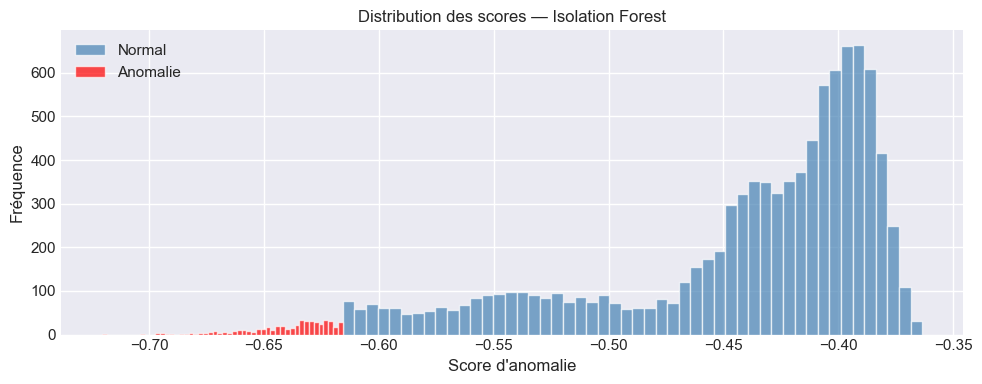

In [44]:
anomalies = df_model_anomaly[df_model_anomaly['anomaly'] == -1]
normales  = df_model_anomaly[df_model_anomaly['anomaly'] == 1]

print(f"Nombre d'anomalies : {len(anomalies)}")
print(f"Nombre normaux     : {len(normales)}")

# Visualisation des scores d'anomalie
plt.figure(figsize=(10, 4))
plt.hist(df_model_anomaly[df_model_anomaly['anomaly'] == 1]['anomaly_score'],
         bins=50, alpha=0.7, color='steelblue', label='Normal', edgecolor='white')
plt.hist(df_model_anomaly[df_model_anomaly['anomaly'] == -1]['anomaly_score'],
         bins=50, alpha=0.7, color='red', label='Anomalie', edgecolor='white')
plt.xlabel('Score d\'anomalie'); plt.ylabel('Fréquence')
plt.title('Distribution des scores — Isolation Forest')
plt.legend(); plt.tight_layout(); plt.show()


## 💾 Sauvegarde du Modèle — Objectif 5.2

In [45]:
os.makedirs('models', exist_ok=True)

joblib.dump(isolation_forest,   'models/model_anomaly_6g.joblib')
joblib.dump(scaler_anomaly,     'models/scaler_anomaly_6g.joblib')
joblib.dump(features_valides,   'models/features_anomaly_6g.joblib')

print('✅ Modèle 5.2 (Isolation Forest) sauvegardé !')
print(f'   Fichier : models/model_anomaly_eya.joblib')
print(f'   Taille  : {os.path.getsize("models/model_anomaly_6g.joblib")/1024:.1f} KB')


✅ Modèle 5.2 (Isolation Forest) sauvegardé !
   Fichier : models/model_anomaly_eya.joblib
   Taille  : 1154.4 KB


---
# 5.3 — Apprentissage en Ligne Adaptatif (Online Learning)

## Problématique

Dans les réseaux 6G, les patterns de trafic évoluent en permanence :
nouvelles technologies, fluctuations de charge, comportements utilisateurs changeants.

**Objectif :** maintenir un modèle de classification de congestion à jour **sans réentraînement complet**,
en utilisant l'apprentissage incrémental pour intégrer chaque nouveau batch de données au fil du temps.

**Modèle choisi :** `SGDClassifier` avec `partial_fit()` — seul classifier sklearn supportant l'apprentissage incrémental natif.

**Avantages clés :**
- ⚡ Mise à jour en quelques ms par batch (vs minutes pour un full retrain)
- 📉 Empreinte mémoire constante — pas besoin de stocker tout l'historique
- 🔄 S'adapte aux concept drifts sans intervention manuelle
- 🚀 Scalable vers des flux temps-réel (Kafka, Flink…)


## 🔧 Préparation du Dataset — Objectif 5.3

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── Chargement ──────────────────────────────────────────────
df_ol = pd.read_csv('network_slicing_congestion_final.csv', encoding='utf-8')
print(f'✅ Dataset chargé — Shape: {df_ol.shape}')

# ── Features (sans data leakage) ────────────────────────────
colonnes_a_exclure_ol = [
    'congestion_class',
    'Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'Rate_Gap',
    'Latency_Score', 'Packet_Loss_Score', 'Jitter_Score', 'Rate_Score',
    'QoS_Probability', 'Efficiency_Index', 'Aggregated_QoS_Score',
    'SLA_Respected'
]

target_col = 'congestion_class'
feature_cols_ol = [c for c in df_ol.columns
                   if c not in colonnes_a_exclure_ol and c != target_col]

# Encodage de la target
le_ol = LabelEncoder()
df_ol['target_enc'] = le_ol.fit_transform(df_ol[target_col].astype(str))

X_ol = df_ol[feature_cols_ol].select_dtypes(include=[np.number])
y_ol = df_ol.loc[X_ol.index, 'target_enc']

# Filtrer classe rare (classe 2 — 1 seul échantillon)
mask = y_ol != le_ol.transform(['2'])[0] if '2' in le_ol.classes_ else np.ones(len(y_ol), dtype=bool)
X_ol = X_ol[mask].reset_index(drop=True)
y_ol = y_ol[mask].reset_index(drop=True)

print(f'Features utilisées : {X_ol.shape[1]}')
print(f'Distribution des classes : {pd.Series(le_ol.inverse_transform(y_ol)).value_counts().to_dict()}')


✅ Dataset chargé — Shape: (10000, 28)
Features utilisées : 15
Distribution des classes : {'1': 5550, '3': 2422, '0': 2027}


## 🔀 Simulation du Flux de Données — Batches Temporels

In [47]:
# ── Split train / test ────────────────────────────────────────
X_train_ol, X_test_ol, y_train_ol, y_test_ol = train_test_split(
    X_ol, y_ol, test_size=0.2, random_state=42, stratify=y_ol
)

# ── Normalisation ─────────────────────────────────────────────
scaler_ol = StandardScaler()
X_train_scaled_ol = scaler_ol.fit_transform(X_train_ol)
X_test_scaled_ol  = scaler_ol.transform(X_test_ol)

# ── Simulation : découpage du train en N batches chronologiques ─
N_BATCHES = 10
batch_size = len(X_train_scaled_ol) // N_BATCHES

batches_X = [X_train_scaled_ol[i*batch_size:(i+1)*batch_size] for i in range(N_BATCHES)]
batches_y = [y_train_ol.values[i*batch_size:(i+1)*batch_size]  for i in range(N_BATCHES)]

print(f'📦 {N_BATCHES} batches de ~{batch_size} exemples chacun')
print(f'   Taille test set : {len(X_test_scaled_ol)} exemples')


📦 10 batches de ~799 exemples chacun
   Taille test set : 2000 exemples


## 🤖 Entraînement Incrémental — SGDClassifier avec `partial_fit()`

In [48]:
# ── Modèle SGD — apprentissage incrémental ───────────────────
classes_all = np.unique(y_ol)

sgd_model = SGDClassifier(
    loss='modified_huber',   # supporte predict_proba
    max_iter=1,              # une passe par batch
    random_state=42,
    n_jobs=-1
)

# ── Boucle d'apprentissage batch par batch ────────────────────
history = []

print('='*60)
print('APPRENTISSAGE INCRÉMENTAL — SGDClassifier')
print('='*60)

for batch_idx, (bX, by) in enumerate(zip(batches_X, batches_y)):
    sgd_model.partial_fit(bX, by, classes=classes_all)

    # Évaluation sur le test set après chaque batch
    y_pred_batch = sgd_model.predict(X_test_scaled_ol)
    acc = accuracy_score(y_test_ol, y_pred_batch)
    f1  = f1_score(y_test_ol, y_pred_batch, average='weighted', zero_division=0)

    history.append({'batch': batch_idx + 1, 'accuracy': acc, 'f1': f1})
    print(f'  Batch {batch_idx+1:2d}/{N_BATCHES} | Accuracy: {acc:.4f} | F1: {f1:.4f}')

print('='*60)
print(f'\n✅ Modèle final — Accuracy: {history[-1]["accuracy"]:.4f} | F1: {history[-1]["f1"]:.4f}')


APPRENTISSAGE INCRÉMENTAL — SGDClassifier
  Batch  1/10 | Accuracy: 0.8130 | F1: 0.7670
  Batch  2/10 | Accuracy: 0.7960 | F1: 0.7111
  Batch  3/10 | Accuracy: 0.7890 | F1: 0.7426
  Batch  4/10 | Accuracy: 0.7790 | F1: 0.7811
  Batch  5/10 | Accuracy: 0.7225 | F1: 0.7361
  Batch  6/10 | Accuracy: 0.7710 | F1: 0.7798
  Batch  7/10 | Accuracy: 0.7970 | F1: 0.7601
  Batch  8/10 | Accuracy: 0.8005 | F1: 0.7215
  Batch  9/10 | Accuracy: 0.8125 | F1: 0.8037
  Batch 10/10 | Accuracy: 0.7945 | F1: 0.7978

✅ Modèle final — Accuracy: 0.7945 | F1: 0.7978


## 📊 Évolution des Performances au Fil des Batches

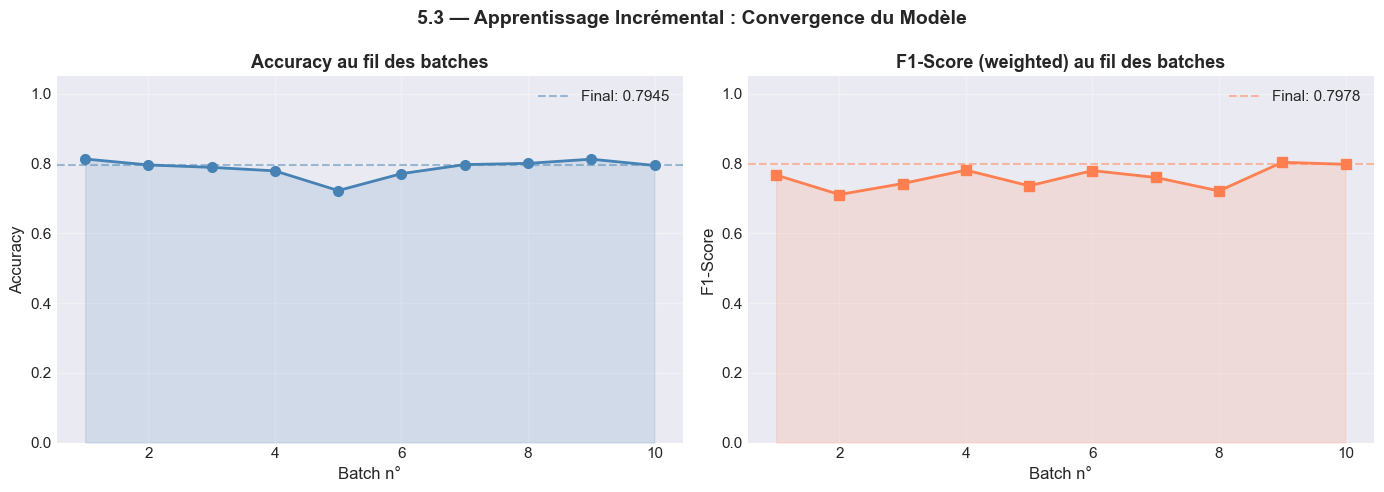


📈 Résumé de la convergence :
 batch  accuracy       f1
     1    0.8130 0.767025
     2    0.7960 0.711119
     3    0.7890 0.742603
     4    0.7790 0.781127
     5    0.7225 0.736061
     6    0.7710 0.779786
     7    0.7970 0.760128
     8    0.8005 0.721494
     9    0.8125 0.803671
    10    0.7945 0.797782


In [49]:
df_history = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──────────────────────────────────────────────────
ax1.plot(df_history['batch'], df_history['accuracy'],
         marker='o', color='steelblue', linewidth=2, markersize=7)
ax1.fill_between(df_history['batch'], df_history['accuracy'],
                 alpha=0.15, color='steelblue')
ax1.set_title('Accuracy au fil des batches', fontsize=13, fontweight='bold')
ax1.set_xlabel('Batch n°'); ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.05); ax1.grid(True, alpha=0.3)
ax1.axhline(df_history['accuracy'].iloc[-1], color='steelblue',
            linestyle='--', alpha=0.5, label=f"Final: {df_history['accuracy'].iloc[-1]:.4f}")
ax1.legend()

# ── F1-Score ──────────────────────────────────────────────────
ax2.plot(df_history['batch'], df_history['f1'],
         marker='s', color='coral', linewidth=2, markersize=7)
ax2.fill_between(df_history['batch'], df_history['f1'],
                 alpha=0.15, color='coral')
ax2.set_title('F1-Score (weighted) au fil des batches', fontsize=13, fontweight='bold')
ax2.set_xlabel('Batch n°'); ax2.set_ylabel('F1-Score')
ax2.set_ylim(0, 1.05); ax2.grid(True, alpha=0.3)
ax2.axhline(df_history['f1'].iloc[-1], color='coral',
            linestyle='--', alpha=0.5, label=f"Final: {df_history['f1'].iloc[-1]:.4f}")
ax2.legend()

plt.suptitle('5.3 — Apprentissage Incrémental : Convergence du Modèle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📈 Résumé de la convergence :')
print(df_history.to_string(index=False))


## 🔄 Validation Croisée — Objectif 5.3 (Simulation Concept Drift)

🔀 Simulation Concept Drift — ajout de bruit sur batches 9 & 10
  Batch  1/10 | Acc: 0.8130 | F1: 0.7670      
  Batch  2/10 | Acc: 0.7960 | F1: 0.7111      
  Batch  3/10 | Acc: 0.7890 | F1: 0.7426      
  Batch  4/10 | Acc: 0.7790 | F1: 0.7811      
  Batch  5/10 | Acc: 0.7225 | F1: 0.7361      
  Batch  6/10 | Acc: 0.7710 | F1: 0.7798      
  Batch  7/10 | Acc: 0.7970 | F1: 0.7601      
  Batch  8/10 | Acc: 0.8005 | F1: 0.7215      
  Batch  9/10 | Acc: 0.7565 | F1: 0.7493 ⚠️  DRIFT
  Batch 10/10 | Acc: 0.6910 | F1: 0.7008 ⚠️  DRIFT


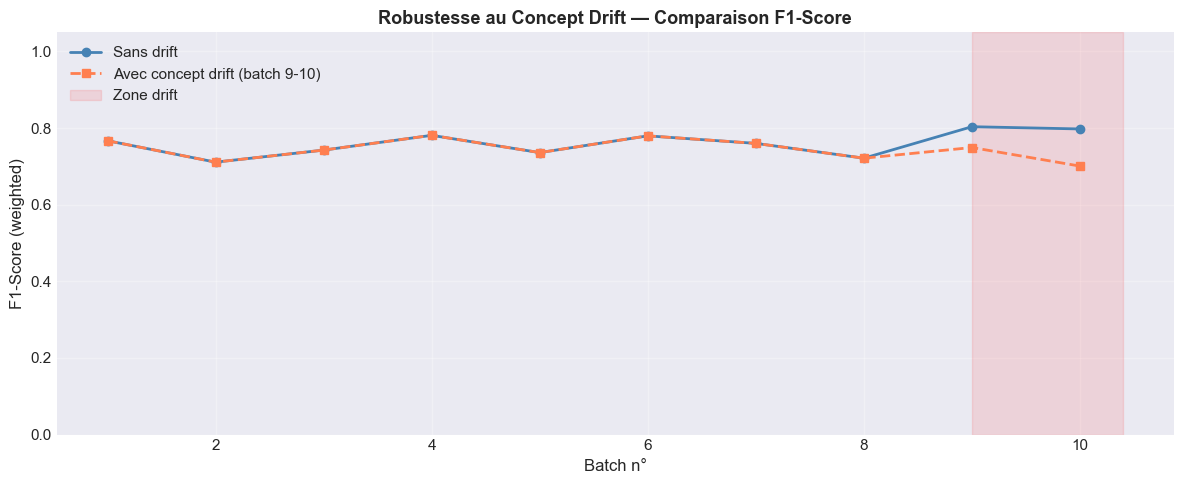

In [50]:
# ── Simulation d'un concept drift : les 2 derniers batches sont ─
# ── perturbés (bruit gaussien ajouté) pour simuler un changement ──
print('🔀 Simulation Concept Drift — ajout de bruit sur batches 9 & 10')
print('='*60)

sgd_drift = SGDClassifier(loss='modified_huber', max_iter=1, random_state=42, n_jobs=-1)
history_drift = []

for batch_idx, (bX, by) in enumerate(zip(batches_X, batches_y)):
    # Simuler drift sur les 2 derniers batches
    if batch_idx >= N_BATCHES - 2:
        noise = np.random.normal(0, 0.5, bX.shape)
        bX = bX + noise

    sgd_drift.partial_fit(bX, by, classes=classes_all)
    y_pred_d = sgd_drift.predict(X_test_scaled_ol)
    acc_d = accuracy_score(y_test_ol, y_pred_d)
    f1_d  = f1_score(y_test_ol, y_pred_d, average='weighted', zero_division=0)
    history_drift.append({'batch': batch_idx + 1, 'accuracy': acc_d, 'f1': f1_d})
    drift_label = '⚠️  DRIFT' if batch_idx >= N_BATCHES - 2 else '     '
    print(f'  Batch {batch_idx+1:2d}/{N_BATCHES} | Acc: {acc_d:.4f} | F1: {f1_d:.4f} {drift_label}')

df_drift = pd.DataFrame(history_drift)

# ── Comparaison modèle normal vs modèle sous drift ─────────────
plt.figure(figsize=(12, 5))
plt.plot(df_history['batch'], df_history['f1'],
         'o-', label='Sans drift', color='steelblue', linewidth=2)
plt.plot(df_drift['batch'], df_drift['f1'],
         's--', label='Avec concept drift (batch 9-10)', color='coral', linewidth=2)
plt.axvspan(9, 10.4, alpha=0.1, color='red', label='Zone drift')
plt.title("Robustesse au Concept Drift — Comparaison F1-Score", fontsize=13, fontweight='bold')
plt.xlabel('Batch n°'); plt.ylabel('F1-Score (weighted)')
plt.ylim(0, 1.05); plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout()
plt.show()


## 📋 Rapport Final — Objectif 5.3

In [52]:
y_pred_final_ol = sgd_model.predict(X_test_scaled_ol)

print('📋 Rapport de classification — SGDClassifier (après apprentissage incrémental)')
print('='*65)
present_classes = sorted(set(y_test_ol) | set(y_pred_final_ol))
present_names   = le_ol.inverse_transform(present_classes)

print(classification_report(
    y_test_ol, y_pred_final_ol,
    labels=present_classes,
    target_names=present_names,
    zero_division=0
))

print('\n📊 Synthèse :')
print(f'  Accuracy finale  : {accuracy_score(y_test_ol, y_pred_final_ol):.4f}')
print(f'  F1 weighted      : {f1_score(y_test_ol, y_pred_final_ol, average="weighted", zero_division=0):.4f}')
print(f'  Batches traités  : {N_BATCHES}')
print(f'  Exemples/batch   : ~{batch_size}')
print(f'  Coût mémoire     : O(features) — constant (pas de stockage historique)')


📋 Rapport de classification — SGDClassifier (après apprentissage incrémental)
              precision    recall  f1-score   support

           0       0.49      0.55      0.52       405
           1       0.83      0.79      0.81      1110
           3       1.00      1.00      1.00       485

    accuracy                           0.79      2000
   macro avg       0.77      0.78      0.78      2000
weighted avg       0.80      0.79      0.80      2000


📊 Synthèse :
  Accuracy finale  : 0.7945
  F1 weighted      : 0.7978
  Batches traités  : 10
  Exemples/batch   : ~799
  Coût mémoire     : O(features) — constant (pas de stockage historique)


## 💾 Sauvegarde du Modèle — Objectif 5.3

In [53]:
os.makedirs('models', exist_ok=True)

joblib.dump(sgd_model,                      'models/model_6G_5_3_sgd_online.joblib')
joblib.dump(scaler_ol,                      'models/scaler_6G_5_3.joblib')
joblib.dump(le_ol,                          'models/encoder_6G_5_3.joblib')
joblib.dump(X_ol.columns.tolist(),          'models/features_6G_5_3.joblib')

print('✅ Modèle 5.3 (SGDClassifier Online Learning) sauvegardé !')
print('   models/model_6G_5_3_sgd_online.joblib')
print('   models/scaler_6G_5_3.joblib')
print('   models/encoder_6G_5_3.joblib')
print('   models/features_6G_5_3.joblib')


✅ Modèle 5.3 (SGDClassifier Online Learning) sauvegardé !
   models/model_6G_5_3_sgd_online.joblib
   models/scaler_6G_5_3.joblib
   models/encoder_6G_5_3.joblib
   models/features_6G_5_3.joblib


---
# 5.4 — Interprétabilité & Dashboard XAI (Explainable AI)

## Problématique

Les modèles de ML déployés en réseau 6G sont des **boîtes noires** pour les opérateurs.
Sans explication des décisions, la confiance et le débogage sont impossibles.

**Objectif :** appliquer **SHAP** (SHapley Additive exPlanations) au meilleur modèle de régression QoS (Objectif 5.1)
et produire un **dashboard interactif** visualisant les facteurs qui influencent chaque décision du modèle.

**Modèle expliqué :** XGBoost Régresseur — prédiction de `QoS_Probability`

**Techniques utilisées :**
- 🔍 **SHAP Global** — importance agrégée sur l'ensemble du dataset
- 🎯 **SHAP Local** — explication d'une décision individuelle (waterfall plot)
- 📊 **SHAP Dependence plots** — interaction feature × prédiction
- 🖥️ **Dashboard matplotlib** — vue consolidée pour opérateurs réseau


## 📦 Installation & Imports — Objectif 5.4

In [54]:
import subprocess, sys
# Installer shap si absent
try:
    import shap
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings('ignore')
shap.initjs()

print(f'✅ SHAP version : {shap.__version__}')


✅ SHAP version : 0.51.0


## 🔧 Reconstruction du Modèle XGBoost — QoS Probability

In [55]:
# ── Chargement du dataset ─────────────────────────────────────
df_xai = pd.read_csv('network_slicing_congestion_final.csv', encoding='utf-8')

epsilon = 1e-9

def safe_sigmoid(x):
    x = np.clip(x, -10, 10)
    return 1 / (1 + np.exp(-x))

# Reconstruire les gaps et la target QoS_Probability
df_xai['Latency_Gap']     = df_xai['Latency Budget (μs)']                  - df_xai['Slice Latency (μs)']
df_xai['Packet_Loss_Gap'] = df_xai['Packet Loss Budget']                   - df_xai['Slice Packet Loss']
df_xai['Jitter_Gap']      = df_xai['Jitter Budget (μs)']                   - df_xai['Slice Jitter (μs)']
df_xai['Rate_Gap']        = df_xai['Slice Available Transfer Rate (Gbps)'] - df_xai['Data Rate Budget (Gbps)']

norm_lat  = df_xai['Latency_Gap']     / (df_xai['Latency Budget (μs)']                  + epsilon)
norm_pkt  = df_xai['Packet_Loss_Gap'] / (df_xai['Packet Loss Budget']                   + epsilon)
norm_jit  = df_xai['Jitter_Gap']      / (df_xai['Jitter Budget (μs)']                   + epsilon)
norm_rate = df_xai['Rate_Gap']        / (df_xai['Slice Available Transfer Rate (Gbps)'] + epsilon)

raw_score = 0.35*norm_lat + 0.30*norm_pkt + 0.20*norm_jit + 0.15*norm_rate
df_xai['QoS_Probability'] = safe_sigmoid(raw_score * 3)

# ── Features & target ─────────────────────────────────────────
feature_names_xai = ['Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'Rate_Gap']
X_xai = df_xai[feature_names_xai]
y_xai = df_xai['QoS_Probability']

X_tr_xai, X_te_xai, y_tr_xai, y_te_xai = train_test_split(
    X_xai, y_xai, test_size=0.2, random_state=42
)

# ── Entraînement XGBoost (tuné) ───────────────────────────────
xgb_xai = XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    random_state=42, verbosity=0
)
xgb_xai.fit(X_tr_xai, y_tr_xai)

y_pred_xai = xgb_xai.predict(X_te_xai)
r2   = r2_score(y_te_xai, y_pred_xai)
rmse = np.sqrt(mean_squared_error(y_te_xai, y_pred_xai))

print(f'✅ XGBoost QoS — R²: {r2:.4f} | RMSE: {rmse:.4f}')
print(f'   Dataset shape : {X_xai.shape}')


✅ XGBoost QoS — R²: 0.9975 | RMSE: 0.0165
   Dataset shape : (10000, 4)


## 🔍 Calcul des Valeurs SHAP

**SHAP (SHapley Additive exPlanations)** est fondé sur la théorie des jeux coopératifs.
Chaque valeur SHAP mesure la contribution marginale d'une feature à la prédiction,
en moyennant sur toutes les coalitions de features possibles.

**Interprétation :**
- `SHAP > 0` → la feature pousse la prédiction **au-dessus** de la moyenne
- `SHAP < 0` → la feature tire la prédiction **en dessous** de la moyenne
- `|SHAP|` → amplitude de l'influence


In [56]:
# ── Explainer SHAP pour XGBoost ───────────────────────────────
explainer_xai = shap.TreeExplainer(xgb_xai)

# Calculer les valeurs SHAP sur le test set (limité à 500 pour la vitesse)
sample_size = min(500, len(X_te_xai))
X_shap_sample = X_te_xai.iloc[:sample_size].reset_index(drop=True)

shap_values = explainer_xai.shap_values(X_shap_sample)
expected_value = explainer_xai.expected_value

print(f'✅ SHAP calculé sur {sample_size} exemples')
print(f'   Expected value (baseline) : {expected_value:.4f}')
print(f'   Shape shap_values         : {np.array(shap_values).shape}')
print(f'\n📊 Importance SHAP moyenne (|SHAP|) par feature :')
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_names_xai
).sort_values(ascending=False)
print(mean_abs_shap.round(4).to_string())


✅ SHAP calculé sur 500 exemples
   Expected value (baseline) : 0.5536
   Shape shap_values         : (500, 4)

📊 Importance SHAP moyenne (|SHAP|) par feature :
Packet_Loss_Gap    0.2269
Jitter_Gap         0.0351
Latency_Gap        0.0326
Rate_Gap           0.0054


## 📊 SHAP Global — Summary Plot (Beeswarm)

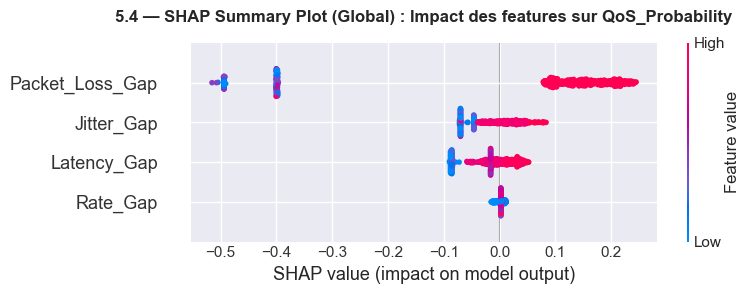

In [57]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_shap_sample,
    feature_names=feature_names_xai,
    plot_type='dot',
    show=False
)
plt.title('5.4 — SHAP Summary Plot (Global) : Impact des features sur QoS_Probability',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


## 📊 SHAP Global — Bar Plot (Importance Agrégée)

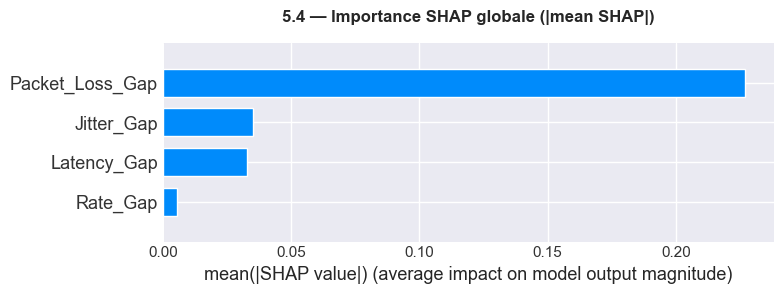

In [58]:
plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_values, X_shap_sample,
    feature_names=feature_names_xai,
    plot_type='bar',
    show=False
)
plt.title('5.4 — Importance SHAP globale (|mean SHAP|)',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


## 🎯 SHAP Local — Explication d'une Décision Individuelle


🟢 Meilleure QoS (SLA respecté) — exemple n°335
  QoS_Probability prédit : 0.8737
  Features :
    Latency_Gap              : 464.0777  (SHAP = +0.0379)
    Packet_Loss_Gap          : 0.0000  (SHAP = +0.2337)
    Jitter_Gap               : 0.8979  (SHAP = +0.0384)
    Rate_Gap                 : 497.0306  (SHAP = +0.0100)


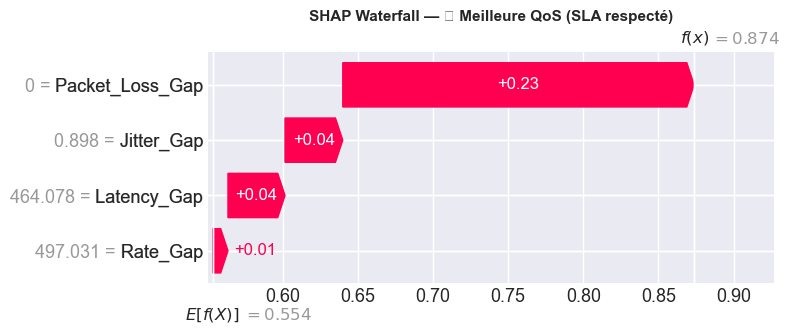


🔴 Pire QoS (SLA violé) — exemple n°43
  QoS_Probability prédit : -0.0002
  Features :
    Latency_Gap              : -1892.4354  (SHAP = -0.0811)
    Packet_Loss_Gap          : -0.0003  (SHAP = -0.3966)
    Jitter_Gap               : -2000.5172  (SHAP = -0.0699)
    Rate_Gap                 : -155.7671  (SHAP = -0.0062)


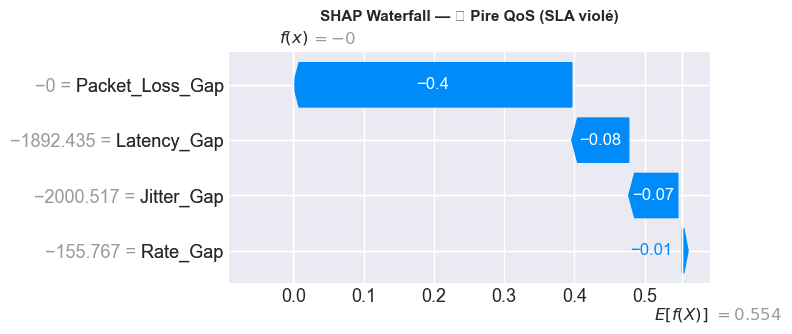

In [59]:
# ── Choisir deux exemples contrastés ──────────────────────────
y_pred_sample = xgb_xai.predict(X_shap_sample)

idx_high = int(np.argmax(y_pred_sample))   # slice avec QoS la plus haute
idx_low  = int(np.argmin(y_pred_sample))   # slice avec QoS la plus basse

for label, idx in [('🟢 Meilleure QoS (SLA respecté)', idx_high),
                   ('🔴 Pire QoS (SLA violé)',          idx_low)]:
    pred = y_pred_sample[idx]
    print(f'\n{label} — exemple n°{idx}')
    print(f'  QoS_Probability prédit : {pred:.4f}')
    print(f'  Features :')
    for feat in feature_names_xai:
        print(f'    {feat:25s}: {X_shap_sample.iloc[idx][feat]:.4f}  '
              f'(SHAP = {shap_values[idx][feature_names_xai.index(feat)]:+.4f})')

    # Waterfall plot
    shap_explanation = shap.Explanation(
        values      = shap_values[idx],
        base_values = expected_value,
        data        = X_shap_sample.iloc[idx].values,
        feature_names = feature_names_xai
    )
    plt.figure(figsize=(9, 4))
    shap.plots.waterfall(shap_explanation, show=False)
    plt.title(f'SHAP Waterfall — {label}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 📈 SHAP Dependence Plots — Interactions Features × Prédiction

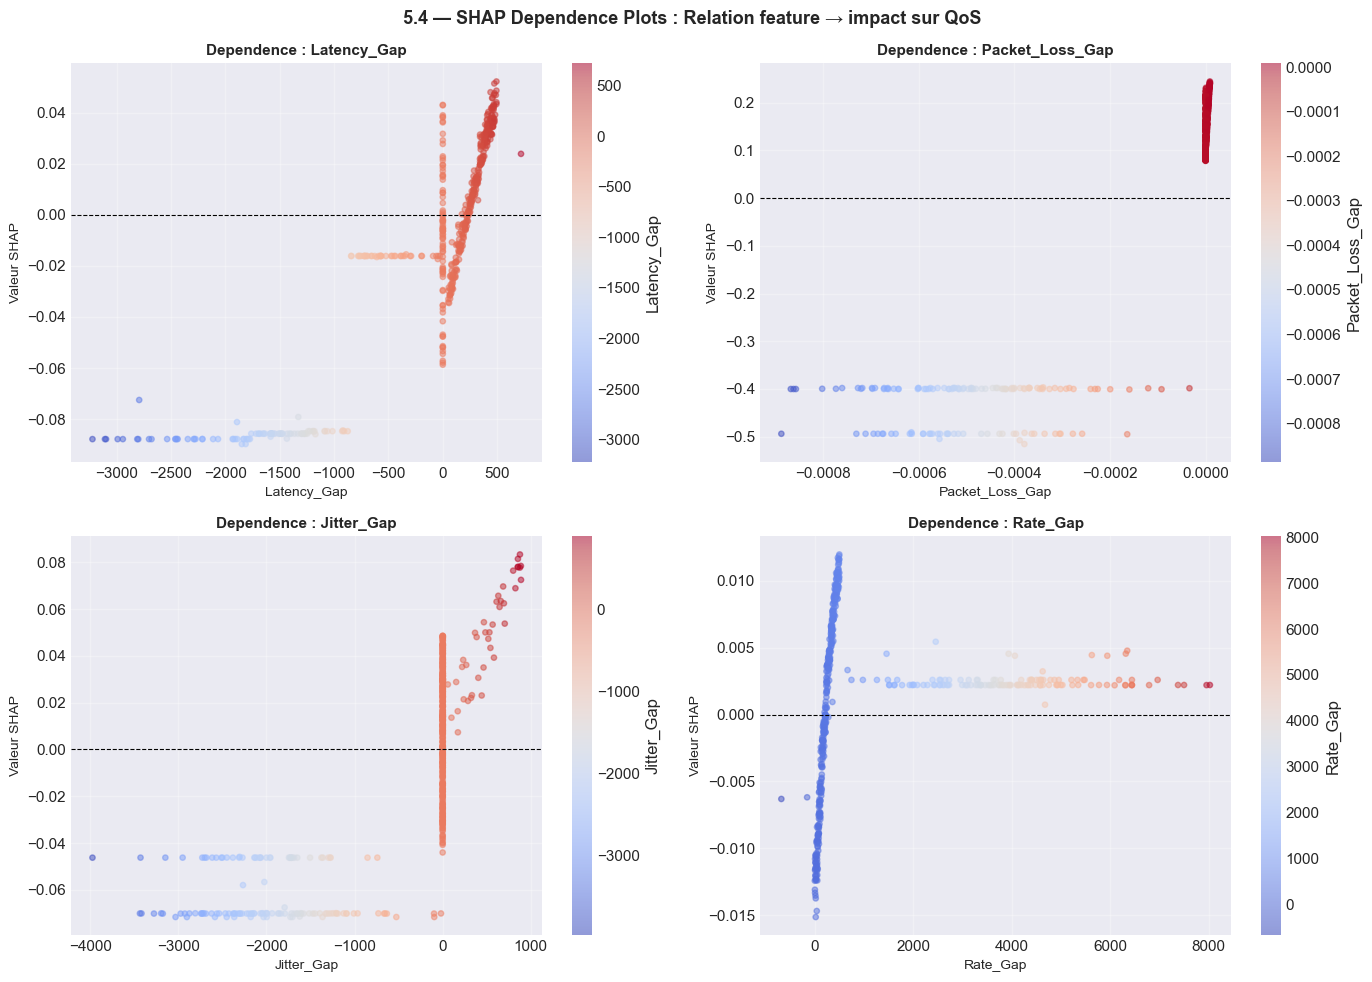

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(feature_names_xai):
    feat_idx = feature_names_xai.index(feat)
    ax = axes[i]

    sc = ax.scatter(
        X_shap_sample[feat],
        shap_values[:, feat_idx],
        c=X_shap_sample[feat],
        cmap='coolwarm', alpha=0.5, s=15
    )
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('Valeur SHAP', fontsize=10)
    ax.set_title(f'Dependence : {feat}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label=feat)

plt.suptitle('5.4 — SHAP Dependence Plots : Relation feature → impact sur QoS',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 🖥️ Dashboard XAI Consolidé — Vue Opérateur Réseau

Le dashboard ci-dessous regroupe sur une seule figure les 4 vues clés
qu'un opérateur réseau consulterait pour auditer les décisions du modèle :

1. **Importance globale** — quelles features comptent le plus en général ?
2. **Distribution SHAP** — comment chaque feature impacte les prédictions ?
3. **Analyse individuelle** — pourquoi ce slice précis a-t-il reçu ce score ?
4. **Matrice de contribution** — vue tabular des SHAP par exemple


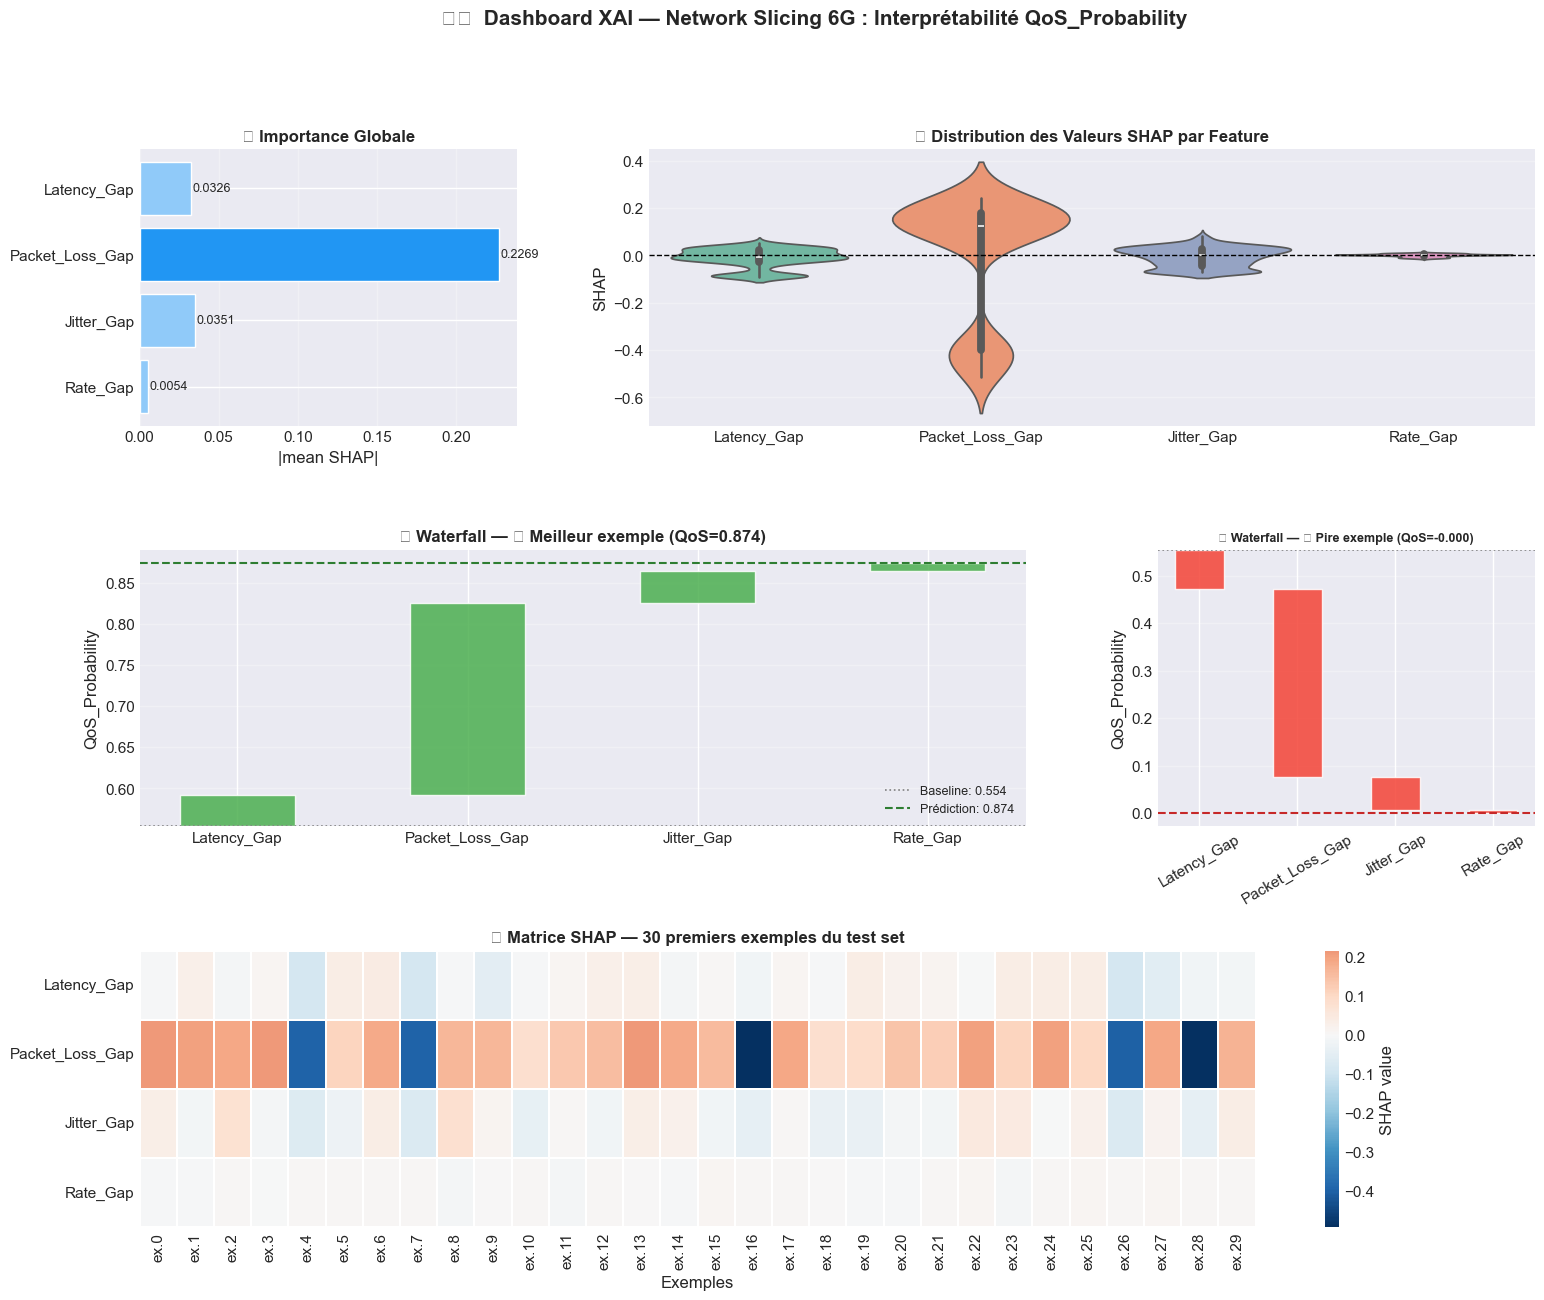

✅ Dashboard sauvegardé → xai_dashboard_6G.png


In [61]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('🖥️  Dashboard XAI — Network Slicing 6G : Interprétabilité QoS_Probability',
             fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1 : Importance globale (bar) ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
mean_abs = np.abs(shap_values).mean(axis=0)
colors_bar = ['#2196F3' if v == max(mean_abs) else '#90CAF9' for v in mean_abs]
bars = ax1.barh(feature_names_xai, mean_abs, color=colors_bar)
ax1.set_xlabel('|mean SHAP|')
ax1.set_title('① Importance Globale', fontweight='bold')
ax1.invert_yaxis()
for bar, val in zip(bars, mean_abs):
    ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
ax1.grid(True, alpha=0.3, axis='x')

# ── Panel 2 : Distribution des SHAP (violinplot) ──────────────
ax2 = fig.add_subplot(gs[0, 1:])
shap_df = pd.DataFrame(shap_values, columns=feature_names_xai)
shap_melted = shap_df.melt(var_name='Feature', value_name='SHAP')
sns.violinplot(data=shap_melted, x='Feature', y='SHAP',
               palette='Set2', inner='box', ax=ax2)
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_title('② Distribution des Valeurs SHAP par Feature', fontweight='bold')
ax2.set_xlabel(''); ax2.grid(True, alpha=0.3, axis='y')

# ── Panel 3 : Waterfall meilleur exemple ──────────────────────
ax3 = fig.add_subplot(gs[1, :2])
shap_high  = shap_values[idx_high]
cumulative = np.cumsum(np.append(expected_value, shap_high))
bar_colors = ['#4CAF50' if v >= 0 else '#F44336' for v in shap_high]
labels_w   = ['baseline'] + feature_names_xai
bottoms    = cumulative[:-1]
ax3.bar(labels_w[1:], shap_high, bottom=bottoms, color=bar_colors, alpha=0.85, width=0.5)
ax3.axhline(expected_value, color='grey', linestyle=':', linewidth=1.2, label=f'Baseline: {expected_value:.3f}')
ax3.axhline(cumulative[-1], color='#2E7D32', linestyle='--', linewidth=1.5,
            label=f'Prédiction: {cumulative[-1]:.3f}')
ax3.set_title(f'③ Waterfall — 🟢 Meilleur exemple (QoS={y_pred_sample[idx_high]:.3f})',
              fontweight='bold')
ax3.set_ylabel('QoS_Probability'); ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# ── Panel 4 : Waterfall pire exemple ──────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
shap_low    = shap_values[idx_low]
cumulative2 = np.cumsum(np.append(expected_value, shap_low))
bar_colors2 = ['#4CAF50' if v >= 0 else '#F44336' for v in shap_low]
ax4.bar(feature_names_xai, shap_low, bottom=cumulative2[:-1],
        color=bar_colors2, alpha=0.85, width=0.5)
ax4.axhline(expected_value, color='grey', linestyle=':', linewidth=1.2)
ax4.axhline(cumulative2[-1], color='#C62828', linestyle='--', linewidth=1.5)
ax4.set_title(f'④ Waterfall — 🔴 Pire exemple (QoS={y_pred_sample[idx_low]:.3f})',
              fontweight='bold', fontsize=9)
ax4.set_ylabel('QoS_Probability')
ax4.tick_params(axis='x', rotation=30)
ax4.grid(True, alpha=0.3, axis='y')

# ── Panel 5 : Heatmap SHAP (30 premiers exemples) ─────────────
ax5 = fig.add_subplot(gs[2, :])
shap_heatmap = pd.DataFrame(shap_values[:30], columns=feature_names_xai)
sns.heatmap(shap_heatmap.T, cmap='RdBu_r', center=0,
            xticklabels=[f'ex.{i}' for i in range(30)],
            yticklabels=feature_names_xai,
            linewidths=0.3, ax=ax5, cbar_kws={'label': 'SHAP value'})
ax5.set_title('⑤ Matrice SHAP — 30 premiers exemples du test set', fontweight='bold')
ax5.set_xlabel('Exemples')

plt.savefig('xai_dashboard_6G.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard sauvegardé → xai_dashboard_6G.png')


## 💾 Sauvegarde du Modèle & Artefacts XAI — Objectif 5.4

In [62]:
os.makedirs('models', exist_ok=True)
os.makedirs('xai_artifacts', exist_ok=True)

# Sauvegarder modèle et explainer
joblib.dump(xgb_xai,             'models/model_6G_5_4_xgboost_xai.joblib')
joblib.dump(explainer_xai,       'xai_artifacts/shap_explainer_5_4.joblib')
joblib.dump(feature_names_xai,   'xai_artifacts/features_5_4.joblib')

# Sauvegarder les valeurs SHAP du test set (pour audit futur)
np.save('xai_artifacts/shap_values_test.npy', shap_values)
X_shap_sample.to_csv('xai_artifacts/X_shap_sample.csv', index=False)

print('✅ Modèle & artefacts XAI sauvegardés !')
print('   models/model_6G_5_4_xgboost_xai.joblib')
print('   xai_artifacts/shap_explainer_5_4.joblib')
print('   xai_artifacts/shap_values_test.npy')
print('   xai_artifacts/X_shap_sample.csv')
print('   xai_dashboard_6G.png')


✅ Modèle & artefacts XAI sauvegardés !
   models/model_6G_5_4_xgboost_xai.joblib
   xai_artifacts/shap_explainer_5_4.joblib
   xai_artifacts/shap_values_test.npy
   xai_artifacts/X_shap_sample.csv
   xai_dashboard_6G.png
